tyjbfgjbgh

In [ ]:
import sys, os, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
import torch

# ── paths ──────────────────────────────────────────────────────────────────
BASE = Path("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/Datasets/Nikhil/Histopathology_Work")
sys.path.insert(0, str(BASE))

IMAGES_DIR       = BASE / "Dataset/multi_images"
MASKS_DIR        = BASE / "Dataset/multi_masks"
CSV_PATH         = BASE / "Dataset/Images_With_Permutations_Labels_Refer_Segmentation_Task.csv"
CSV_STATIC_PATH  = BASE / "Dataset/Images_With_Unique_Labels_Refer_Segmentation_Task.csv"
CKPT_PATH        = BASE / "experiments/cipsnet_v2/experiments/LVIT_IE_DINOv2_ViTB14_Perm_Actual_100ep/fold_1/checkpoints/best.pth"
OUT_DIR          = Path("vis_output"); OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Checkpoint exists:", CKPT_PATH.exists())
print("Perm CSV exists:  ", CSV_PATH.exists())
print("Static CSV exists:", CSV_STATIC_PATH.exists())
print("Images dir:", IMAGES_DIR.exists(), "  Masks dir:", MASKS_DIR.exists())


Device: cpu
Checkpoint exists: True
Perm CSV exists:   True
Static CSV exists: True
Images dir: True   Masks dir: True


In [4]:
# Class colours matching minor_class.png  (RGB, 0-255)
# Background = BLACK (for clean mask saves)
CLASS_COLORS = {
    0: (  0,   0,   0),   # background – black
    1: (255,   0,   0),   # Neoplastic  – red
    2: (  0,   0, 255),   # Inflammatory – blue
    3: (  0, 255,   0),   # Connective  – green
    4: (255, 255,   0),   # Dead        – yellow
    5: (255,   0, 255),   # Epithelial  – magenta
}
CLASS_NAMES = {
    0: "Background",
    1: "Neoplastic",
    2: "Inflammatory",
    3: "Connective",
    4: "Dead",
    5: "Epithelial",
}
# CSV class name → type id  (matches type_map values from post-processing)
CSV_TO_TYPE = {
    "Neoplastic":             1,
    "Inflammatory":           2,
    "Connective_Soft_tissue": 3,
    "Dead":                   4,
    "Epithelial":             5,
}
# GT mask channel index per class
CLASS_CHANNEL = {
    "Neoplastic":             0,
    "Inflammatory":           1,
    "Connective_Soft_tissue": 2,
    "Dead":                   3,
    "Epithelial":             4,
}

print("CLASS_COLORS (background = black):")
for tid, (rgb, name) in enumerate(zip(CLASS_COLORS.values(), CLASS_NAMES.values())):
    print(f"  {tid}: {name:20s}  {rgb}")
print("Color setup confirmed.")


CLASS_COLORS (background = black):
  0: Background            (0, 0, 0)
  1: Neoplastic            (255, 0, 0)
  2: Inflammatory          (0, 0, 255)
  3: Connective            (0, 255, 0)
  4: Dead                  (255, 255, 0)
  5: Epithelial            (255, 0, 255)
Color setup confirmed.


In [5]:
from experiments.cipsnet_v2.models import create_lvit_ie_model

model = create_lvit_ie_model(
    num_classes=6,
    freeze_text_encoder=True,
    img_size=256,
    backbone="dinov2_vit_b_14",
    instance_embed_dim=16,
    use_gradient_checkpointing=False,
)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE).eval()
print(f"Loaded checkpoint from epoch {ckpt.get('epoch', '?')}")
print("Model ready.")

2026-02-26 22:37:58.239979: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 22:37:58.269000: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 22:37:59.330352: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[LViT-IE] Using DINOv2 backbone: dinov2_vit_b_14
[DINOv2] Loading pretrained dinov2_vit_b_14 from torch hub...


Using cache found in /home/miglab/.cache/torch/hub/facebookresearch_dinov2_main
/home/miglab/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/miglab/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/miglab/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


[DINOv2] Initialized dinov2_vit_b_14:
  - Embed dim: 768, Patch size: 14
  - Num layers: 12
  - Mid features from layer 6
  - Deep features from layer 11
  - Output dim: 768
  - Grid size: 18×18
[LViT-IE] Total parameters: 202,626,754
[LViT-IE] Trainable parameters: 94,316,482
Loaded checkpoint from epoch 61
Model ready.


In [6]:
import cv2
import numpy as np
import pandas as pd
import json, shutil, random
from pathlib import Path
from PIL import Image as PILImage
from experiments.cipsnet_v2.testing.instance_embed_postprocess import (
    process_batch_ie, IEPostProcessConfig
)

IE_CFG = IEPostProcessConfig()

CSV_TO_TYPE = {
    "Neoplastic": 1, "Inflammatory": 2,
    "Connective_Soft_tissue": 3, "Dead": 4, "Epithelial": 5,
}
CLASS_COLORS = {
    0: (0,0,0), 1: (255,0,0), 2: (0,0,255),
    3: (0,255,0), 4: (255,255,0), 5: (255,0,255),
}
CLASS_NAMES = {0:"Background",1:"Neoplastic",2:"Inflammatory",
               3:"Connective",4:"Dead",5:"Epithelial"}
CLASS_CHANNEL = {
    "Neoplastic":0,"Inflammatory":1,"Connective_Soft_tissue":2,"Dead":3,"Epithelial":4,
}

df_perm   = pd.read_csv(CSV_PATH)
df_static = pd.read_csv(CSV_STATIC_PATH)
df_perm_tr   = df_perm[df_perm['image_path'].str.contains('fold_2|fold_3')].copy()
df_static_tr = df_static[df_static['image_path'].str.contains('fold_2|fold_3')].copy()

def load_image_tensor(img_filename):
    img = cv2.imread(str(IMAGES_DIR / img_filename))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (256, 256))
    tensor = torch.from_numpy(img_resized.transpose(2, 0, 1)).float() / 255.0
    return img_resized, tensor.unsqueeze(0).to(DEVICE)

@torch.no_grad()
def predict(img_tensor, instruction):
    outputs = model(images=img_tensor, texts=[instruction], instance_maps=None)
    result  = process_batch_ie(
        pred_np=outputs['np'], pred_dist=outputs['dist'],
        pred_embed=outputs['embed'], pred_type=outputs['type'], config=IE_CFG,
    )[0]
    return result['type_map']

# ── Build per-image GT class sets from perm CSV ──────────────────────────
single_rows = df_perm_tr[~df_perm_tr['classes'].str.contains(';')]
cls_per_img = single_rows.groupby('image_path')['classes'].apply(set).reset_index()
cls_per_img.columns = ['image_path', 'class_set']
cls_per_img['n_gt']    = cls_per_img['class_set'].apply(len)
cls_per_img['has_dead'] = cls_per_img['class_set'].apply(lambda s: 'Dead' in s)
cls_per_img['has_epi']  = cls_per_img['class_set'].apply(lambda s: 'Epithelial' in s)

# Group by tissue type
cls_per_img['tissue'] = cls_per_img['image_path'].str.split('_').str[1]

# Already-good images to keep
KEEP = {
    "1_Colon_fold_2_1298_img.png",   # 5-class, predicts 4
    "1_Colon_fold_2_1808_img.png",   # 5-class, predicts 4
    "1_Colon_fold_2_2483_img.png",   # 5-class, predicts 4
    "1_Colon_fold_2_2484_img.png",   # 5-class, predicts 4
    "1_Bile-duct_fold_3_1490_img.png",  # 4-class Epi, predicts 3
    "1_Esophagus_fold_2_1022_img.png",  # 4-class Epi, predicts 3
}

# ── SCAN: find candidates with 3-class GT, diverse tissues ───────────────
# Bucket A: exactly 3 GT classes, from tissues NOT already in KEEP
three_class = cls_per_img[cls_per_img['n_gt'] == 3].copy()
# Exclude Colon (already saturated), exclude images already in KEEP
three_class = three_class[~three_class['image_path'].isin(KEEP)]
three_class = three_class[three_class['tissue'] != 'Colon']
tissues_3 = sorted(three_class['tissue'].unique())
print(f"3-class candidate tissues: {tissues_3}")
print(f"3-class candidate count: {len(three_class)}\n")

# Sample up to 4 per tissue, then we'll quick-test
random.seed(7)
cands_3cls = []
for tissue in tissues_3:
    pool = three_class[three_class['tissue'] == tissue]['image_path'].tolist()
    cands_3cls.extend(random.sample(pool, min(4, len(pool))))
print(f"Sampling {len(cands_3cls)} candidates from 3-class non-Colon tissues...")

# ── Quick inference test on candidates ───────────────────────────────────
print(f"\n{'img':<50} {'n_gt':>5} {'tissue':<15} {'n_pred':>6}  predicted")
print("-"*110)
scan_results = []
for img_path in cands_3cls:
    p_rows = df_perm_tr[df_perm_tr['image_path'] == img_path]
    if len(p_rows) == 0:
        continue
    all_row = p_rows.iloc[p_rows['classes'].str.count(';').argmax()]
    _, img_t = load_image_tensor(img_path)
    tmap     = predict(img_t, all_row['instruction'])
    predicted = [t for t in np.unique(tmap) if t > 0]
    n_gt = int(cls_per_img[cls_per_img['image_path']==img_path]['n_gt'].values[0])
    tissue = img_path.split('_')[1]
    print(f"{img_path:<50} {n_gt:>5} {tissue:<15} {len(predicted):>6}  {[CLASS_NAMES[t] for t in predicted]}")
    scan_results.append({'image_path': img_path, 'n_gt': n_gt, 'tissue': tissue,
                         'n_pred': len(predicted), 'pred': predicted})

# Show best per tissue
print("\n--- Best candidate per tissue (highest n_pred) ---")
df_scan = pd.DataFrame(scan_results)
if len(df_scan):
    best = df_scan.sort_values('n_pred', ascending=False).drop_duplicates('tissue')
    print(best[['image_path','tissue','n_gt','n_pred','pred']].to_string())


3-class candidate tissues: ['Bile-duct', 'Bladder', 'Breast', 'Cervix', 'Esophagus', 'Lung', 'Pancreatic', 'Prostate', 'Skin', 'Testis', 'Thyroid']
3-class candidate count: 366

Sampling 39 candidates from 3-class non-Colon tissues...

img                                                 n_gt tissue          n_pred  predicted
--------------------------------------------------------------------------------------------------------------
1_Bile-duct_fold_3_1338_img.png                        3 Bile-duct            1  ['Neoplastic']
1_Bile-duct_fold_2_1428_img.png                        3 Bile-duct            2  ['Connective', 'Epithelial']
1_Bile-duct_fold_3_1505_img.png                        3 Bile-duct            1  ['Neoplastic']
1_Bile-duct_fold_2_1281_img.png                        3 Bile-duct            2  ['Neoplastic', 'Connective']
1_Bladder_fold_2_0817_img.png                          3 Bladder              1  ['Neoplastic']
1_Bladder_fold_3_1561_img.png                         

In [ ]:
# =========================
# PARAMS, MACs (G), FPS
# =========================

import torch
import time
import numpy as np

# -------------------------
# 1. Dummy input
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dummy_img = torch.rand(1, 3, 256, 256, device=DEVICE)
dummy_text = ["random text words here now"]  # 5 words

# -------------------------
# 2. Parameter count
# -------------------------
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_params(model)
print(f"Total Params      : {total_params/1e6:.3f} M")
print(f"Trainable Params  : {trainable_params/1e6:.3f} M")

# -------------------------
# 3. MACs (G)
# Uses fvcore (recommended for transformers)
# pip install fvcore
# -------------------------
from fvcore.nn import FlopCountAnalysis

model.eval()

with torch.no_grad():
    flops = FlopCountAnalysis(
        model,
        inputs=(dummy_img, dummy_text, None)
    )

total_macs = flops.total() / 1e9
print(f"MACs              : {total_macs:.3f} G")

# -------------------------
# 4. FPS measurement
# -------------------------
def measure_fps(model, img, text, warmup=20, iters=100):
    model.eval()

    with torch.no_grad():
        # Warmup
        for _ in range(warmup):
            _ = model(images=img, texts=text, instance_maps=None)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        for _ in range(iters):
            _ = model(images=img, texts=text, instance_maps=None)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        end = time.time()

    fps = iters / (end - start)
    return fps

fps = measure_fps(model, dummy_img, dummy_text)
print(f"FPS               : {fps:.2f}")

# -------------------------
# Optional: latency
# -------------------------
latency_ms = 1000.0 / fps
print(f"Latency           : {latency_ms:.2f} ms")

Total Params      : 202.627 M
Trainable Params  : 94.316 M


Unsupported operator aten::add encountered 55 time(s)
Unsupported operator aten::embedding encountered 3 time(s)
Unsupported operator aten::add_ encountered 1 time(s)
Unsupported operator aten::sub encountered 3 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 24 time(s)
Unsupported operator aten::gelu encountered 27 time(s)
Unsupported operator aten::mul encountered 38 time(s)
Unsupported operator aten::upsample_bicubic2d encountered 1 time(s)
Unsupported operator aten::div encountered 1 time(s)
Unsupported operator aten::unflatten encountered 1 time(s)
Unsupported operator aten::softmax encountered 1 time(s)
Unsupported operator aten::sigmoid encountered 5 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their

MACs              : 52.634 G
FPS               : 6.17
Latency           : 161.97 ms


In [5]:
# ── Final curated 12 images after quality analysis ─────────────────────
# Diversity: 5-class(×4), 4-class(×2), 3-class(×6)
# Tissues: Colon, Bile-duct, Esophagus, Cervix, Thyroid, Breast, Pancreatic, Prostate
# Notable: two images with Inflammatory (1298, Cervix_1188), Dead in all-5-class images

SELECTED_IMAGES = [
    # ── 5-class GT, 4 predicted ──────────────────────────────────────────
    "1_Colon_fold_2_1298_img.png",    # Neo+Inflam+Dead+Epi  ← unique Inflammatory!
    "1_Colon_fold_2_1808_img.png",    # Neo+Conn+Dead+Epi
    "1_Colon_fold_2_2483_img.png",    # Neo+Conn+Dead+Epi
    "1_Colon_fold_2_2484_img.png",    # Neo+Conn+Dead+Epi
    # ── 4-class GT, 3 predicted — different tissues ──────────────────────
    "1_Bile-duct_fold_3_1490_img.png",# Neo+Conn+Epi
    "1_Esophagus_fold_2_1022_img.png",# Neo+Conn+Epi
    # ── 3-class GT, 2 predicted — diverse tissues ────────────────────────
    "3_Cervix_fold_2_1188_img.png",   # Neo+Inflam  ← Inflammatory in small patch
    "1_Bile-duct_fold_2_1428_img.png",# Conn+Epi
    "1_Thyroid_fold_2_0977_img.png",  # Neo+Conn  ← new tissue
    "1_Breast_fold_3_0837_img.png",   # Neo+Conn
    "1_Pancreatic_fold_2_2168_img.png",# Neo+Conn  ← new tissue
    "1_Prostate_fold_2_2239_img.png", # Neo+Conn  ← new tissue
]

samples = []
for img_path in SELECTED_IMAGES:
    perm_rows   = df_perm_tr[df_perm_tr['image_path'] == img_path]
    static_rows = df_static_tr[df_static_tr['image_path'] == img_path]
    single_classes = sorted(
        perm_rows[~perm_rows['classes'].str.contains(';')]['classes'].tolist(),
        key=lambda x: CSV_TO_TYPE.get(x, 99)
    )
    samples.append({
        'image_path':         img_path,
        'single_classes':     single_classes,
        'perm_rows':          perm_rows,
        'static_instruction': static_rows.iloc[0]['instruction'] if len(static_rows) > 0 else None,
    })
    n_perm = 2**len(single_classes) - 1
    print(f"  {img_path:<52}  {len(single_classes)}-class GT  ({n_perm} perms)  classes: {single_classes}")

print(f"\nTotal: {len(samples)} images")


  1_Colon_fold_2_1298_img.png                           5-class GT  (31 perms)  classes: ['Neoplastic', 'Inflammatory', 'Connective_Soft_tissue', 'Dead', 'Epithelial']
  1_Colon_fold_2_1808_img.png                           5-class GT  (31 perms)  classes: ['Neoplastic', 'Inflammatory', 'Connective_Soft_tissue', 'Dead', 'Epithelial']
  1_Colon_fold_2_2483_img.png                           5-class GT  (31 perms)  classes: ['Neoplastic', 'Inflammatory', 'Connective_Soft_tissue', 'Dead', 'Epithelial']
  1_Colon_fold_2_2484_img.png                           5-class GT  (31 perms)  classes: ['Neoplastic', 'Inflammatory', 'Connective_Soft_tissue', 'Dead', 'Epithelial']
  1_Bile-duct_fold_3_1490_img.png                       4-class GT  (15 perms)  classes: ['Neoplastic', 'Inflammatory', 'Connective_Soft_tissue', 'Epithelial']
  1_Esophagus_fold_2_1022_img.png                       4-class GT  (15 perms)  classes: ['Neoplastic', 'Inflammatory', 'Connective_Soft_tissue', 'Epithelial']
  3_Cerv

In [6]:
import cv2
import torchvision.transforms.functional as TF
from experiments.cipsnet_v2.testing.instance_embed_postprocess import (
    process_batch_ie, IEPostProcessConfig
)

IE_CFG = IEPostProcessConfig()

def load_image_tensor(img_filename):
    """Load a 256×256 image and return both the display RGB and the model tensor."""
    img = cv2.imread(str(IMAGES_DIR / img_filename))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (256, 256))
    tensor = torch.from_numpy(img_resized.transpose(2, 0, 1)).float() / 255.0
    return img_resized, tensor.unsqueeze(0).to(DEVICE)   # (H,W,3),  (1,3,H,W)

def type_map_to_rgb(type_map):
    """Convert integer type map → RGB image using CLASS_COLORS."""
    H, W = type_map.shape
    rgb = np.zeros((H, W, 3), dtype=np.uint8)
    for tid, color in CLASS_COLORS.items():
        rgb[type_map == tid] = color
    return rgb

@torch.no_grad()
def predict(img_tensor, instruction):
    """Run model forward + post-process; return type_map (H,W) int array."""
    outputs = model(images=img_tensor, texts=[instruction], instance_maps=None)
    result = process_batch_ie(
        pred_np=outputs['np'],
        pred_dist=outputs['dist'],
        pred_embed=outputs['embed'],
        pred_type=outputs['type'],
        config=IE_CFG,
    )[0]
    return result['type_map']   # numpy (H,W), values 0-5

# Quick sanity check on one image
img_rgb, img_t = load_image_tensor(samples[0]['image_path'])
row0 = samples[0]['perm_rows'].iloc[0]
tmap = predict(img_t, row0['instruction'])
print("type_map unique values:", np.unique(tmap))
print("Sanity check passed.")


type_map unique values: [0 3]
Sanity check passed.


In [7]:
# ── Quick quality preview: run all-class perm instruction for each sample ─
print("Previewing predictions on new training-fold samples...\n")
print(f"{'#':<3} {'image':<45} {'instr_classes':<45} {'type_map_classes'}")
print("-" * 140)
for i, s in enumerate(samples):
    img_rgb_s, img_t_s = load_image_tensor(s['image_path'])
    # find the all-class (max combo) row
    all_row = s['perm_rows'].iloc[s['perm_rows']['classes'].str.count(';').argmax()]
    tmap_s  = predict(img_t_s, all_row['instruction'])
    unique_types = [CLASS_NAMES[t] for t in np.unique(tmap_s) if t > 0]
    print(f"{i+1:<3} {s['image_path']:<45} {all_row['classes']:<45} {unique_types}")


Previewing predictions on new training-fold samples...

#   image                                         instr_classes                                 type_map_classes
--------------------------------------------------------------------------------------------------------------------------------------------
1   1_Colon_fold_2_1298_img.png                   Connective_Soft_tissue;Dead;Epithelial;Inflammatory;Neoplastic ['Neoplastic', 'Inflammatory', 'Dead', 'Epithelial']
2   1_Colon_fold_2_1808_img.png                   Connective_Soft_tissue;Dead;Epithelial;Inflammatory;Neoplastic ['Neoplastic', 'Connective', 'Dead', 'Epithelial']
3   1_Colon_fold_2_2483_img.png                   Connective_Soft_tissue;Dead;Epithelial;Inflammatory;Neoplastic ['Neoplastic', 'Connective', 'Dead', 'Epithelial']
4   1_Colon_fold_2_2484_img.png                   Connective_Soft_tissue;Dead;Epithelial;Inflammatory;Neoplastic ['Neoplastic', 'Connective', 'Dead', 'Epithelial']
5   1_Bile-duct_fold_3_1490_img.

In [9]:
# ── Test ALL 21 five-class images → pick best 4 by n_predicted_classes ────
print("Testing all 21 five-class training images...\n")
all5_results = []
for img_path in all5_imgs:
    img_rgb_x, img_t_x = load_image_tensor(img_path)
    perm_rows_x = df_perm_tr[df_perm_tr['image_path'] == img_path]
    all_row_x   = perm_rows_x.iloc[perm_rows_x['classes'].str.count(';').argmax()]
    tmap_x      = predict(img_t_x, all_row_x['instruction'])
    predicted   = [t for t in np.unique(tmap_x) if t > 0]
    all5_results.append({
        'image_path': img_path,
        'n_pred':     len(predicted),
        'pred_names': [CLASS_NAMES[t] for t in predicted],
    })
    print(f"  {img_path:<50}  n_pred={len(predicted)}  {[CLASS_NAMES[t] for t in predicted]}")

all5_results.sort(key=lambda x: x['n_pred'], reverse=True)
print("\n--- RANKING (best first) ---")
for r in all5_results:
    print(f"  n={r['n_pred']}  {r['image_path']}")


Testing all 21 five-class training images...



NameError: name 'all5_imgs' is not defined

In [7]:
import cv2

# ── pure-pixel save (no axes, no titles, no borders) ──────────────────────
def save_img(arr_rgb, path):
    """Save a numpy uint8 RGB array as PNG using PIL – zero matplotlib overhead."""
    Image.fromarray(arr_rgb.astype(np.uint8)).save(str(path))

# ── short file-safe name for a class combo string ─────────────────────────
def short_name(cls_str):
    return (cls_str
            .replace('Connective_Soft_tissue', 'Conn')
            .replace('Inflammatory', 'Inflam')
            .replace('Neoplastic', 'Neo')
            .replace('Epithelial', 'Epi')
            .replace('Dead', 'Dead')
            .replace(';', '_'))

# ── ground-truth mask for one class (from channel PNG) ────────────────────
def load_gt_class_mask(img_filename, class_name):
    """Return RGB (H,W,3) with class color on black; None if mask file missing."""
    prefix   = img_filename.replace('_img.png', '')
    ch       = CLASS_CHANNEL[class_name]
    mask_png = MASKS_DIR / f"{prefix}_channel_{ch}_{class_name}.png"
    if not mask_png.exists():
        return None
    m   = cv2.imread(str(mask_png), cv2.IMREAD_GRAYSCALE)
    rgb = np.zeros((*m.shape, 3), dtype=np.uint8)
    rgb[m > 0] = CLASS_COLORS[CSV_TO_TYPE[class_name]]
    return rgb

# ── extract single class from a type_map → RGB on black ──────────────────
def extract_class_rgb(type_map, class_id):
    rgb = np.zeros((*type_map.shape, 3), dtype=np.uint8)
    rgb[type_map == class_id] = CLASS_COLORS[class_id]
    return rgb

# ── full combined type_map → RGB on black (all classes) ──────────────────
def type_map_to_rgb_combined(type_map):
    rgb = np.zeros((*type_map.shape, 3), dtype=np.uint8)
    for tid, color in CLASS_COLORS.items():
        if tid > 0:
            rgb[type_map == tid] = color
    return rgb

# ── permutation prediction: only show classes in the query ───────────────
def type_map_to_rgb_perm(type_map, cls_ids):
    """Color only the queried class ids; everything else stays black."""
    rgb = np.zeros((*type_map.shape, 3), dtype=np.uint8)
    for tid in cls_ids:
        rgb[type_map == tid] = CLASS_COLORS[tid]
    return rgb

# ── look up instruction from perm CSV rows ───────────────────────────────
def get_instr(rows, cls_combo_str):
    m = rows[rows['classes'] == cls_combo_str]
    return m.iloc[0]['instruction'] if len(m) > 0 else None

print("Helper functions defined.")
# Quick sanity: check GT mask exists for first sample
s0 = samples[0]
gt = load_gt_class_mask(s0['image_path'], s0['single_classes'][0])
print(f"GT mask test: {s0['single_classes'][0]} shape={gt.shape if gt is not None else 'MISSING'}")


Helper functions defined.
GT mask test: Neoplastic shape=(256, 256, 3)


In [12]:
# ── Full clean regeneration of all 12 images ─────────────────────────────
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir()
print("Cleaned vis_output/\n")

for idx, s in enumerate(samples):
    img_fn  = s['image_path']
    s_cls   = s['single_classes']
    p_rows  = s['perm_rows']
    s_instr = s['static_instruction']

    folder = OUT_DIR / f"{idx+1:02d}_{img_fn.replace('_img.png', '')}"
    folder.mkdir(parents=True)
    instructions = {}
    img_rgb, img_t = load_image_tensor(img_fn)

    print(f"[{idx+1}/12] {img_fn}  ({len(s_cls)}-class GT, {2**len(s_cls)-1} perms)")

    # (1) original
    save_img(img_rgb, folder / "original.png")

    # (2) GT per class
    for cls in s_cls:
        gt_rgb = load_gt_class_mask(img_fn, cls)
        if gt_rgb is not None:
            save_img(gt_rgb, folder / f"gt_{short_name(cls)}.png")

    # (3) static prediction — per class + combined
    if s_instr:
        static_tmap = predict(img_t, s_instr)
        for cls in s_cls:
            tid   = CSV_TO_TYPE[cls]
            fname = f"static_{short_name(cls)}.png"
            save_img(extract_class_rgb(static_tmap, tid), folder / fname)
            instructions[fname] = s_instr
        combined_fname = "static_combined.png"
        save_img(type_map_to_rgb_combined(static_tmap), folder / combined_fname)
        instructions[combined_fname] = s_instr
        print(f"  static: {len(s_cls)} per-class + combined")

    # (4) all 2^N-1 permutation predictions
    perm_count = 0
    for _, row in p_rows.iterrows():
        cls_str = row['classes']
        instr   = row['instruction']
        tmap    = predict(img_t, instr)
        cls_ids = [CSV_TO_TYPE[c] for c in cls_str.split(';') if c in CSV_TO_TYPE]
        fname   = f"perm_{short_name(cls_str)}.png"
        save_img(type_map_to_rgb_perm(tmap, cls_ids), folder / fname)
        instructions[fname] = instr
        perm_count += 1
    print(f"  perm:   {perm_count} combos")

    # (5) instructions JSON
    with open(folder / "instructions.json", "w") as f:
        json.dump(instructions, f, indent=2)

    total_pngs = len(list(folder.glob("*.png")))
    print(f"  total:  {total_pngs} PNGs\n")

print("=" * 60)
print("Done! Final vis_output structure:")
for d in sorted(OUT_DIR.iterdir()):
    if d.is_dir():
        n = len(list(d.glob("*.png")))
        tissue = d.name.split('_')[2]
        print(f"  {d.name:<55} {n:>3} PNGs  ({tissue})")


Cleaned vis_output/

[1/12] 1_Colon_fold_2_1298_img.png  (5-class GT, 31 perms)
  static: 5 per-class + combined
  perm:   31 combos
  total:  43 PNGs

[2/12] 1_Colon_fold_2_1808_img.png  (5-class GT, 31 perms)
  static: 5 per-class + combined
  perm:   31 combos
  total:  43 PNGs

[3/12] 1_Colon_fold_2_2483_img.png  (5-class GT, 31 perms)
  static: 5 per-class + combined
  perm:   31 combos
  total:  43 PNGs

[4/12] 1_Colon_fold_2_2484_img.png  (5-class GT, 31 perms)
  static: 5 per-class + combined
  perm:   31 combos
  total:  43 PNGs

[5/12] 1_Bile-duct_fold_3_1490_img.png  (4-class GT, 15 perms)
  static: 4 per-class + combined
  perm:   15 combos
  total:  25 PNGs

[6/12] 1_Esophagus_fold_2_1022_img.png  (4-class GT, 15 perms)
  static: 4 per-class + combined
  perm:   15 combos
  total:  25 PNGs

[7/12] 3_Cervix_fold_2_1188_img.png  (3-class GT, 7 perms)
  static: 3 per-class + combined
  perm:   7 combos
  total:  15 PNGs

[8/12] 1_Bile-duct_fold_2_1428_img.png  (3-class GT, 7 

In [8]:
from PIL import Image as PILImage
import numpy as np, os

def pix_coverage(img_path):
    """Fraction of non-black pixels in a mask PNG."""
    arr = np.array(PILImage.open(img_path).convert("RGB"))
    nonblack = np.any(arr > 10, axis=-1).sum()
    return nonblack / (arr.shape[0] * arr.shape[1])

def iou_masks(gt_path, pred_path):
    """Binary IoU between two colour masks (any non-black pixel = foreground)."""
    gt   = np.any(np.array(PILImage.open(gt_path).convert("RGB"))   > 10, axis=-1)
    pred = np.any(np.array(PILImage.open(pred_path).convert("RGB")) > 10, axis=-1)
    inter = (gt & pred).sum()
    union = (gt | pred).sum()
    return inter / union if union > 0 else 0.0

OUT = OUT_DIR
rows_data = []

for folder in sorted(OUT.iterdir()):
    if not folder.is_dir():
        continue
    fname = folder.name

    # identify which classes this folder has via its gt files
    gt_files = sorted(folder.glob("gt_*.png"))
    cls_list = [g.stem.replace("gt_", "") for g in gt_files]

    gt_covs, iou_vals = [], []
    for cls in cls_list:
        gt_p   = folder / f"gt_{cls}.png"
        pred_p = folder / f"static_{cls}.png"
        if gt_p.exists():
            gt_covs.append(pix_coverage(gt_p))
        if gt_p.exists() and pred_p.exists():
            iou_vals.append(iou_masks(gt_p, pred_p))

    mean_gt_cov  = np.mean(gt_covs)   if gt_covs  else 0
    mean_iou     = np.mean(iou_vals)  if iou_vals else 0

    # also check combined static vs combined GT (any class present)
    orig = np.array(PILImage.open(folder / "original.png").convert("RGB"))
    comb_cov = pix_coverage(folder / "static_combined.png") if (folder/"static_combined.png").exists() else 0

    rows_data.append({
        "folder":       fname,
        "classes":      ", ".join(cls_list),
        "n_classes":    len(cls_list),
        "mean_gt_cov":  round(mean_gt_cov,  3),
        "mean_iou":     round(mean_iou,     3),
        "comb_cov":     round(comb_cov,     3),
    })

df_rank = pd.DataFrame(rows_data).sort_values("mean_iou", ascending=False).reset_index(drop=True)
df_rank.index += 1
print(df_rank[["folder","classes","n_classes","mean_gt_cov","mean_iou","comb_cov"]].to_string())


                         folder                       classes  n_classes  mean_gt_cov  mean_iou  comb_cov
1   11_1_Pancreatic_fold_2_2168             Conn, Inflam, Neo          3        0.050     0.288     0.135
2       10_1_Breast_fold_3_0837             Conn, Inflam, Neo          3        0.059     0.286     0.154
3       07_3_Cervix_fold_2_1188             Conn, Inflam, Neo          3        0.106     0.177     0.381
4     12_1_Prostate_fold_2_2239                Conn, Epi, Neo          3        0.061     0.169     0.080
5    08_1_Bile-duct_fold_2_1428             Conn, Epi, Inflam          3        0.039     0.104     0.140
6        02_1_Colon_fold_2_1808  Conn, Dead, Epi, Inflam, Neo          5        0.017     0.060     0.383
7        01_1_Colon_fold_2_1298  Conn, Dead, Epi, Inflam, Neo          5        0.048     0.041     0.364
8      09_1_Thyroid_fold_2_0977             Conn, Inflam, Neo          3        0.007     0.035     0.023
9    06_1_Esophagus_fold_2_1022        Conn, E

In [13]:
# ── deeper analysis: perm all-class vs static, and scan training folds ────

print("=" * 70)
print("PART A: perm_all vs static_combined coverage per folder")
print("=" * 70)
for folder in sorted(OUT.iterdir()):
    if not folder.is_dir():
        continue
    # find the all-class perm file (longest class combo)
    perm_files = sorted(folder.glob("perm_*.png"), key=lambda x: len(x.name), reverse=True)
    perm_all = perm_files[0] if perm_files else None
    static_comb = folder / "static_combined.png"
    perm_cov    = pix_coverage(perm_all)    if perm_all    else 0
    static_cov  = pix_coverage(static_comb) if static_comb.exists() else 0

    # Per-class perm single predictions
    single_perms = sorted(folder.glob("perm_[A-Z]*.png"), key=lambda x: len(x.name))
    single_perms = [p for p in single_perms if '_' not in p.stem.replace('perm_','')]
    single_covs  = {p.stem.replace('perm_',''): round(pix_coverage(p),3) for p in single_perms}

    print(f"\n{folder.name}")
    print(f"  static_combined cov : {static_cov:.3f}")
    print(f"  perm_all cov        : {perm_cov:.3f}  ({perm_all.name if perm_all else 'N/A'})")
    print(f"  per-class perm cov  : {single_covs}")

print("\n" + "=" * 70)
print("PART B: Find training-fold images with all 5 classes")
print("=" * 70)
# model is fold_1 checkpoint → trained on fold_2 + fold_3 data
train_perm = df_perm[df_perm['image_path'].str.contains('fold_2|fold_3')].copy()
single_tr  = train_perm[~train_perm['classes'].str.contains(';')]
cls_per_img = single_tr.groupby('image_path')['classes'].apply(set).reset_index()
cls_per_img.columns = ['image_path', 'class_set']
# 5-class images
all5 = cls_per_img[cls_per_img['class_set'] == {
    'Neoplastic','Inflammatory','Connective_Soft_tissue','Dead','Epithelial'}]
print(f"Training-fold images with ALL 5 classes: {len(all5)}")
print(all5['image_path'].head(20).to_list())

# 4-class images by Dead presence
dead4 = cls_per_img[cls_per_img['class_set'].apply(lambda s: 'Dead' in s and len(s) >= 4)]
print(f"\nTraining-fold images with Dead + ≥3 others: {len(dead4)}")
print(dead4['image_path'].head(10).to_list())


PART A: perm_all vs static_combined coverage per folder

01_1_Breast_fold_1_0095
  static_combined cov : 0.292
  perm_all cov        : 0.293  (perm_Conn_Epi_Inflam_Neo.png)
  per-class perm cov  : {'Epi': 0.176, 'Neo': 0.251, 'Conn': 0.005, 'Inflam': 0.0}

02_1_Bile-duct_fold_1_1593
  static_combined cov : 0.000
  perm_all cov        : 0.151  (perm_Conn_Epi_Inflam_Neo.png)
  per-class perm cov  : {'Epi': 0.0, 'Neo': 0.063, 'Conn': 0.022, 'Inflam': 0.0}

03_1_Breast_fold_1_1715
  static_combined cov : 0.286
  perm_all cov        : 0.285  (perm_Conn_Epi_Inflam_Neo.png)
  per-class perm cov  : {'Epi': 0.186, 'Neo': 0.199, 'Conn': 0.0, 'Inflam': 0.0}

04_1_Breast_fold_1_0678
  static_combined cov : 0.243
  perm_all cov        : 0.244  (perm_Conn_Epi_Inflam_Neo.png)
  per-class perm cov  : {'Epi': 0.158, 'Neo': 0.172, 'Conn': 0.023, 'Inflam': 0.0}

05_1_Breast_fold_1_0537
  static_combined cov : 0.000
  perm_all cov        : 0.233  (perm_Conn_Epi_Inflam_Neo.png)
  per-class perm cov  : {'Ep

In [8]:

# ── Load VLM baseline models (LAVT, CRIS, LViT) ──────────────────────────
import sys
sys.path.insert(0, str(BASE))

from experiments.cipsnet_v2.models import create_lavt_model, create_cris_model, create_lvit_model
from experiments.cipsnet_v2.testing.post_processing import process_batch, PostProcessConfig

BASELINE_CKPTS = {
    "LAVT": BASE / "experiments/cipsnet_v2/experiments/LAVT_20260213_000906_Static_Dataloader_Weighted_Focal_100epoch/fold_1/checkpoints/best.pth",
    "CRIS": BASE / "experiments/cipsnet_v2/experiments/CRIS_20260211_174530_Static_Dataloader/fold_1/checkpoints/best.pth",
    "LViT": BASE / "experiments/cipsnet_v2/experiments/LVIT_20260213_000653_Permutation_Dataloader_Weighted_Focal_100epoch/fold_1/checkpoints/best.pth",
}

# Model factory for each variant
def load_baseline_model(variant, ckpt_path):
    if variant == "LAVT":
        m = create_lavt_model(num_classes=6)
    elif variant == "CRIS":
        m = create_cris_model(num_classes=6)
    elif variant == "LViT":
        m = create_lvit_model(num_classes=6)
    else:
        raise ValueError(variant)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    state = ckpt.get('model_state_dict', ckpt.get('model', ckpt))
    m.load_state_dict(state)
    m = m.to(DEVICE).eval()
    print(f"  Loaded {variant} from epoch {ckpt.get('epoch', '?')}")
    return m

baseline_models = {}
for vname, cpath in BASELINE_CKPTS.items():
    print(f"Loading {vname} ...")
    baseline_models[vname] = load_baseline_model(vname, cpath)

HV_CFG = PostProcessConfig()

@torch.no_grad()
def predict_hv(model, variant, img_tensor, instruction):
    """Run HV-head models (LAVT, CRIS, LViT) → type_map."""
    if variant == "LAVT":
        outputs = model(images=img_tensor, instructions=[instruction])
    else:
        outputs = model(images=img_tensor, texts=[instruction])
    results = process_batch(
        pred_np=outputs['np'],
        pred_hv=outputs['hv'],
        pred_type=outputs['type'],
        config=HV_CFG,
    )
    return results[0]['type_map']   # numpy (H,W)

print("\nAll baseline models ready.")


Loading LAVT ...

LAVT Nuclei Segmenter Configuration
Architecture: LAVT-style (Early Fusion)
Components:
  - Text Encoder: emilyalsentzer/Bio_ClinicalBERT
  - Image Encoder: ViT-B/16 with Language-Aware blocks
  - Text injection: Every ViT layer (12 layers)
  - Decoder: HoVer-Net style (NP + HV + Type)
  - Embed Dim: 768
  - Num Classes: 6

  Loaded LAVT from epoch 33
Loading CRIS ...
  Loaded CRIS from epoch 27
Loading LViT ...
[LViT] Using ViT-B/16 backbone (ImageNet pretrained)
[LViT] Total parameters: 201,591,661
[LViT] Trainable parameters: 93,281,389
  Loaded LViT from epoch 47

All baseline models ready.


In [10]:

# ── Generate VLM baseline predictions for all 12 selected images ──────────
# Output: vis_output/<folder>/lavt_combined.png, cris_combined.png, lvit_combined.png
# Each is the full-class combined type_map coloured with CLASS_COLORS

import shutil
from PIL import Image as PILImage

VIS_BASELINES_DIR = OUT_DIR  # reuse existing vis_output folders

print("Generating VLM baseline predictions...\n")
print(f"{'#':<3} {'image':<45} {'LAVT classes':<30} {'CRIS classes':<30} {'LViT classes'}")
print("-" * 140)

for idx, s in enumerate(samples):
    img_fn  = s['image_path']
    s_instr = s['static_instruction']
    if s_instr is None:
        print(f"{idx+1:<3} {img_fn:<45} SKIPPED (no static instruction)")
        continue

    folder = VIS_BASELINES_DIR / f"{idx+1:02d}_{img_fn.replace('_img.png', '')}"
    folder.mkdir(parents=True, exist_ok=True)

    _, img_t = load_image_tensor(img_fn)

    row_names = []
    for vname, vmodel in baseline_models.items():
        tmap = predict_hv(vmodel, vname, img_t, s_instr)
        # Save combined coloured prediction
        rgb  = type_map_to_rgb_combined(tmap)
        save_img(rgb, folder / f"{vname.lower()}_combined.png")
        classes = [CLASS_NAMES[t] for t in np.unique(tmap) if t > 0]
        row_names.append(f"{classes}")

    print(f"{idx+1:<3} {img_fn:<45} {row_names[0]:<30} {row_names[1]:<30} {row_names[2]}")

print("\nDone! Baseline predictions saved to vis_output/<folder>/lavt_combined.png etc.")


Generating VLM baseline predictions...

#   image                                         LAVT classes                   CRIS classes                   LViT classes
--------------------------------------------------------------------------------------------------------------------------------------------
1   1_Colon_fold_2_1298_img.png                   ['Inflammatory', 'Connective', 'Epithelial'] ['Neoplastic']                 ['Neoplastic']
2   1_Colon_fold_2_1808_img.png                   ['Inflammatory', 'Epithelial'] ['Neoplastic']                 ['Neoplastic']
3   1_Colon_fold_2_2483_img.png                   ['Inflammatory', 'Connective'] []                             []
4   1_Colon_fold_2_2484_img.png                   ['Neoplastic', 'Inflammatory', 'Connective', 'Epithelial'] ['Neoplastic', 'Inflammatory'] ['Neoplastic']
5   1_Bile-duct_fold_3_1490_img.png               ['Neoplastic', 'Inflammatory', 'Connective'] []                             []
6   1_Esophagus_fold_2_1022

Contrast ranking  (↑ = CIPS-Net best AND baselines worst):
                         folder  cips_iou  lavt_iou  cris_iou  lvit_iou  contrast
1     12_1_Prostate_fold_2_2239     0.425     0.280     0.000     0.152     0.281
2    08_1_Bile-duct_fold_2_1428     0.731     0.595     0.231     0.623     0.248
3       07_3_Cervix_fold_2_1188     0.628     0.466     0.084     0.664     0.223
4        04_1_Colon_fold_2_2484     0.569     0.462     0.068     0.587     0.197
5       10_1_Breast_fold_3_0837     0.707     0.406     0.607     0.543     0.188
6   11_1_Pancreatic_fold_2_2168     0.700     0.420     0.544     0.633     0.168
7        01_1_Colon_fold_2_1298     0.607     0.512     0.329     0.490     0.163
8    06_1_Esophagus_fold_2_1022     0.644     0.533     0.403     0.618     0.126
9      09_1_Thyroid_fold_2_0977     0.450     0.338     0.355     0.475     0.061
10       02_1_Colon_fold_2_1808     0.198     0.343     0.165     0.354    -0.090
11       03_1_Colon_fold_2_2483     0.0

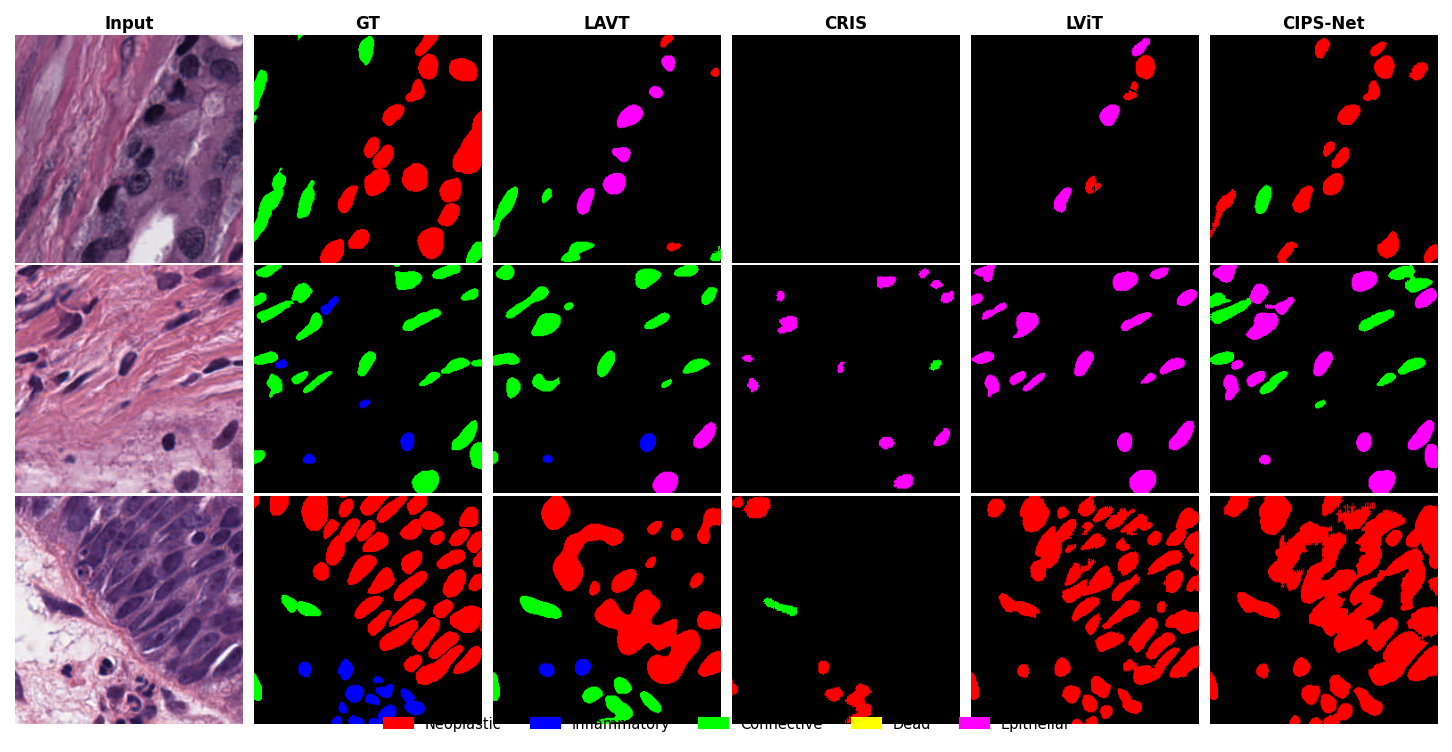

Saved: vis_output/comparison_figure.png
Saved: vis_output/comparison_figure_hires.png


In [12]:

# ── Build paper comparison figure: N rows × 6 cols ────────────────────────
# Columns: Input | GT (all classes) | LAVT | CRIS | LViT | CIPS-Net
# Row selection: MAXIMISE contrast = CIPS-Net IoU  −  mean(LAVT+CRIS+LViT IoU)
#   → best CIPS-Net rows where baselines fail most visually

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd
from PIL import Image as PILImage
from pathlib import Path

TOP_N     = 3
COLS      = ["Input", "GT", "LAVT", "CRIS", "LViT", "CIPS-Net"]
FIG_OUT   = Path("vis_output/comparison_figure.png")
PAPER_FIG = Path("vis_output/comparison_figure_hires.png")

# ── helpers ───────────────────────────────────────────────────────────────
def load_gt_combined(folder):
    """Merge all per-class GT masks into one RGB image."""
    rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for gf in sorted(folder.glob("gt_*.png")):
        arr = np.array(PILImage.open(gf).convert("RGB"))
        mask = np.any(arr > 10, axis=-1)
        rgb[mask] = arr[mask]
    return rgb

def binary_iou_arrays(a_rgb, b_rgb):
    """Binary IoU: any non-black pixel = foreground."""
    a = np.any(np.asarray(a_rgb) > 10, axis=-1)
    b = np.any(np.asarray(b_rgb) > 10, axis=-1)
    inter = (a & b).sum(); union = (a | b).sum()
    return float(inter) / union if union > 0 else 0.0

# ── Compute contrast score for every folder ───────────────────────────────
contrast_rows = []
for _, row in df_rank.iterrows():
    folder   = OUT_DIR / row["folder"]
    gt_comb  = load_gt_combined(folder)

    cips_f   = folder / "static_combined.png"
    cips_iou = binary_iou_arrays(gt_comb, PILImage.open(cips_f).convert("RGB")) if cips_f.exists() else 0.0

    base_ious = {}
    for bname in ["lavt", "cris", "lvit"]:
        bf = folder / f"{bname}_combined.png"
        base_ious[bname] = binary_iou_arrays(gt_comb, PILImage.open(bf).convert("RGB")) if bf.exists() else 0.0

    mean_base = float(np.mean(list(base_ious.values())))
    contrast  = cips_iou - mean_base          # higher = CIPS better, baselines worse

    contrast_rows.append({
        "folder":        row["folder"],
        "classes":       row["classes"],
        "cips_iou":      round(cips_iou, 3),
        "lavt_iou":      round(base_ious["lavt"], 3),
        "cris_iou":      round(base_ious["cris"], 3),
        "lvit_iou":      round(base_ious["lvit"], 3),
        "mean_base_iou": round(mean_base, 3),
        "contrast":      round(contrast, 3),
    })

df_contrast = (pd.DataFrame(contrast_rows)
               .sort_values("contrast", ascending=False)
               .reset_index(drop=True))
df_contrast.index += 1
print("Contrast ranking  (↑ = CIPS-Net best AND baselines worst):")
print(df_contrast[["folder","cips_iou","lavt_iou","cris_iou","lvit_iou","contrast"]].to_string())

# ── Select TOP_N by contrast ───────────────────────────────────────────────
top_folders = df_contrast.head(TOP_N)["folder"].tolist()
print(f"\nSelected {TOP_N} rows for the comparison figure:")
for f in top_folders:
    print(f"  {f}")

# ── Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    TOP_N, len(COLS),
    figsize=(len(COLS) * 1.6, TOP_N * 1.6),
    dpi=150,
)

for row_i, folder_name in enumerate(top_folders):
    folder   = OUT_DIR / folder_name
    img_rgb  = np.array(PILImage.open(folder / "original.png").convert("RGB"))
    gt_rgb   = load_gt_combined(folder)
    lavt_rgb = np.array(PILImage.open(folder / "lavt_combined.png").convert("RGB"))
    cris_rgb = np.array(PILImage.open(folder / "cris_combined.png").convert("RGB"))
    lvit_rgb = np.array(PILImage.open(folder / "lvit_combined.png").convert("RGB"))
    cips_rgb = np.array(PILImage.open(folder / "static_combined.png").convert("RGB"))

    imgs = [img_rgb, gt_rgb, lavt_rgb, cris_rgb, lvit_rgb, cips_rgb]
    for col_i, (img, title) in enumerate(zip(imgs, COLS)):
        ax = axes[row_i][col_i]
        ax.imshow(img)
        ax.axis("off")
        if row_i == 0:
            ax.set_title(title, fontsize=8, fontweight="bold", pad=3)

legend_patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS[i]) / 255, label=CLASS_NAMES[i])
    for i in range(1, 6)
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=5,
    fontsize=7,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)
plt.tight_layout(pad=0.3, h_pad=0.3, w_pad=0.3)
fig.savefig(str(FIG_OUT),   dpi=150, bbox_inches="tight")
fig.savefig(str(PAPER_FIG), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_OUT}")
print(f"Saved: {PAPER_FIG}")


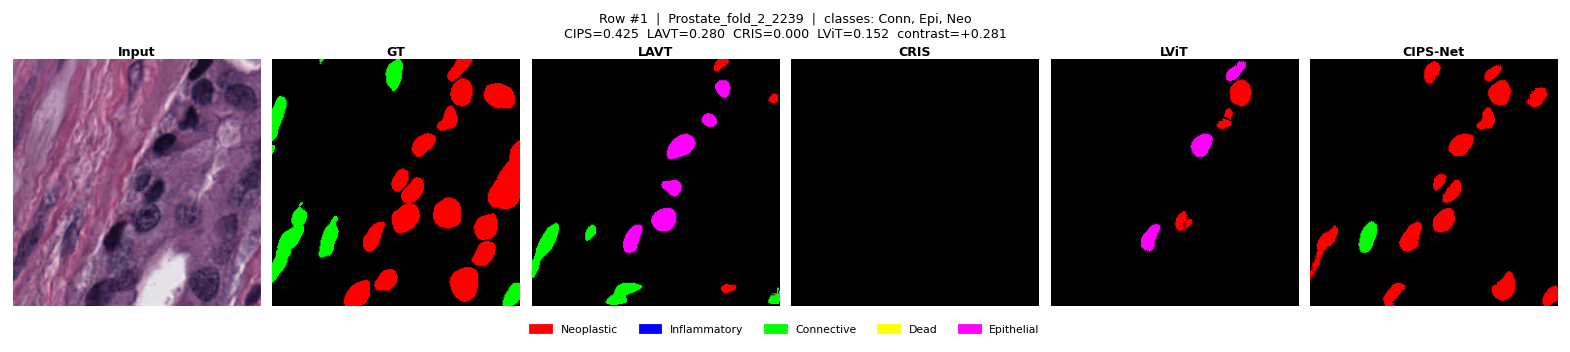

  → saved row_01_12_1_Prostate_fold_2_2239.png


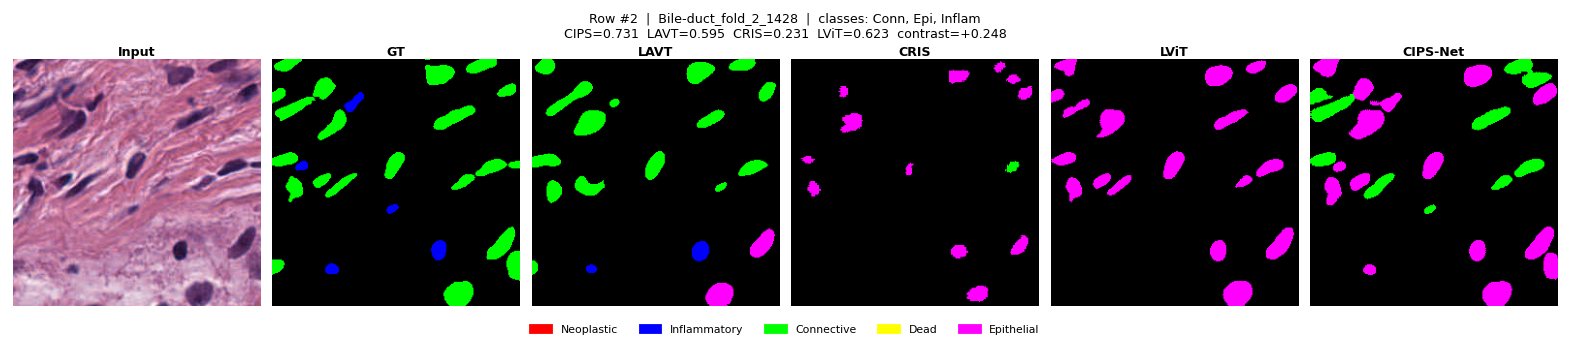

  → saved row_02_08_1_Bile-duct_fold_2_1428.png


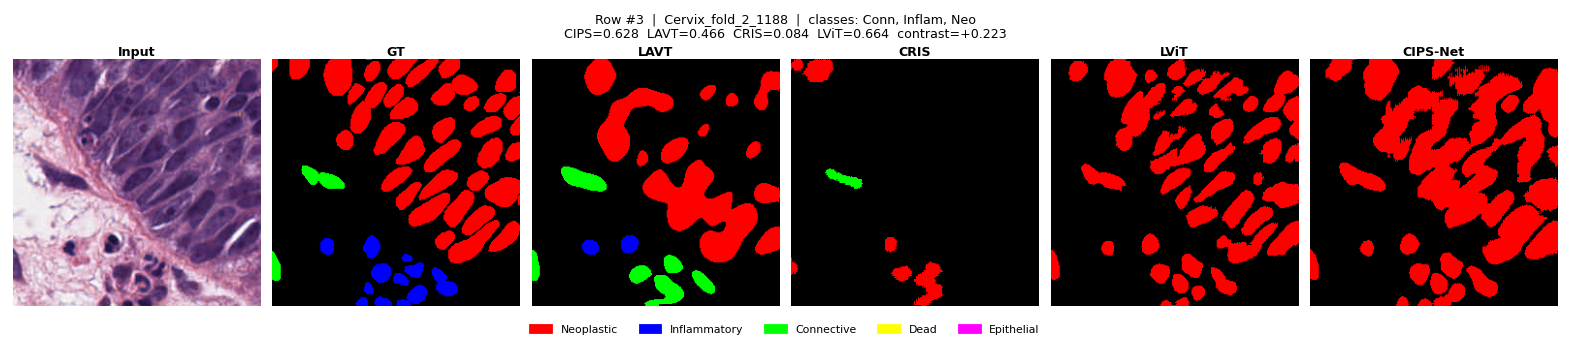

  → saved row_03_07_3_Cervix_fold_2_1188.png


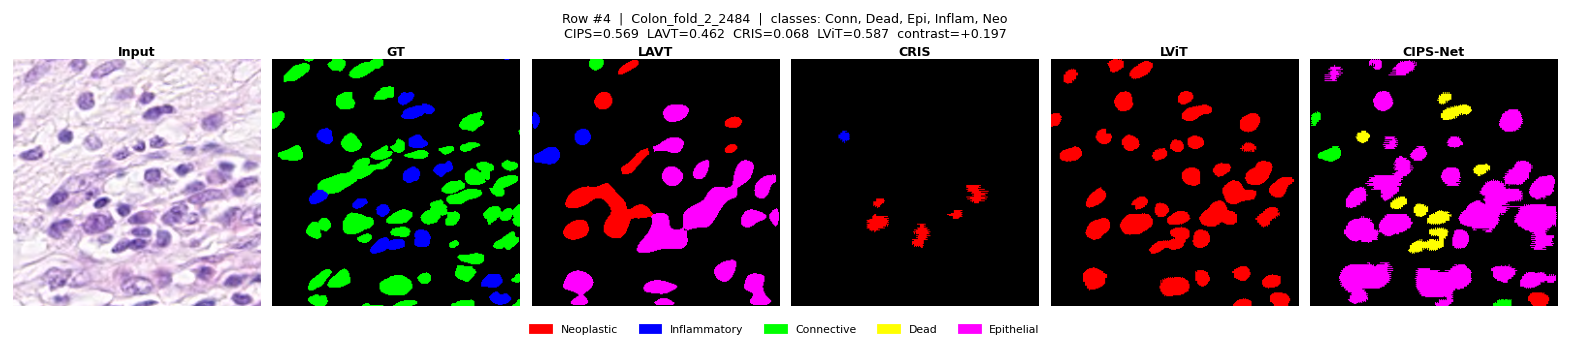

  → saved row_04_04_1_Colon_fold_2_2484.png


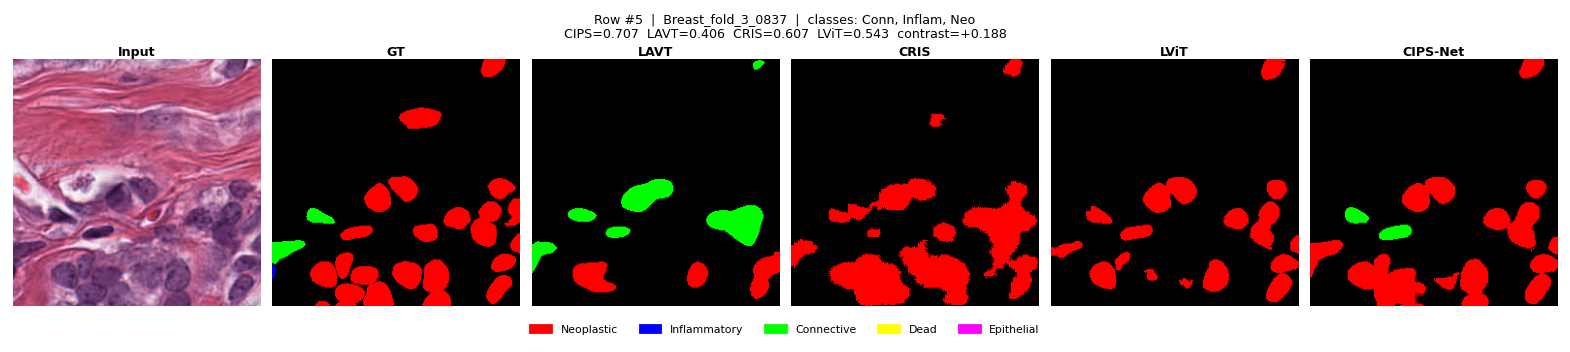

  → saved row_05_10_1_Breast_fold_3_0837.png


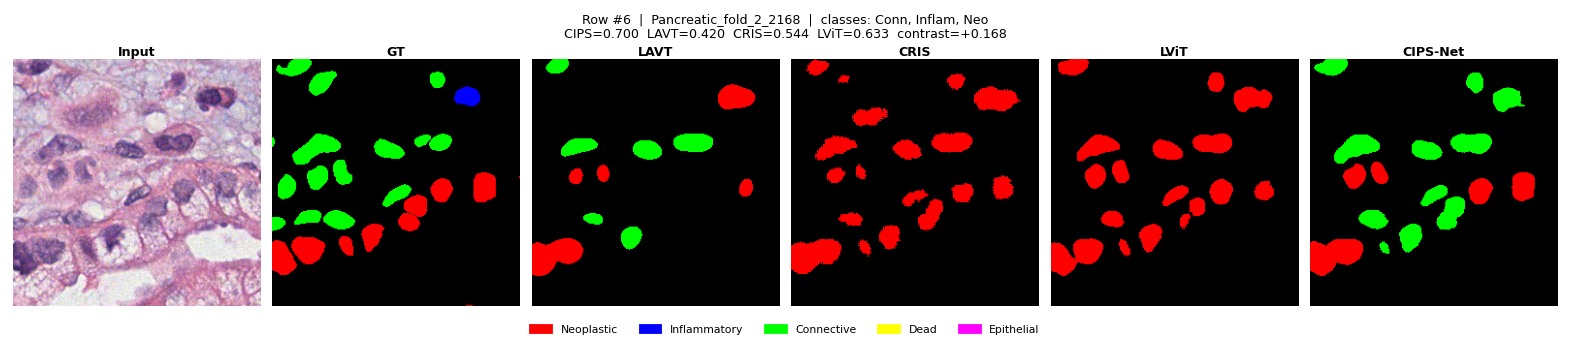

  → saved row_06_11_1_Pancreatic_fold_2_2168.png


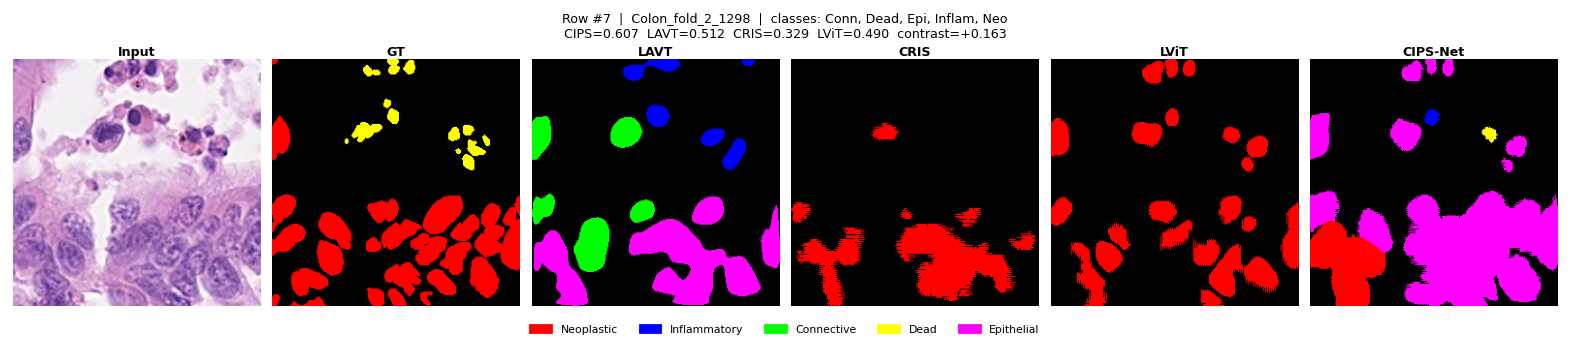

  → saved row_07_01_1_Colon_fold_2_1298.png


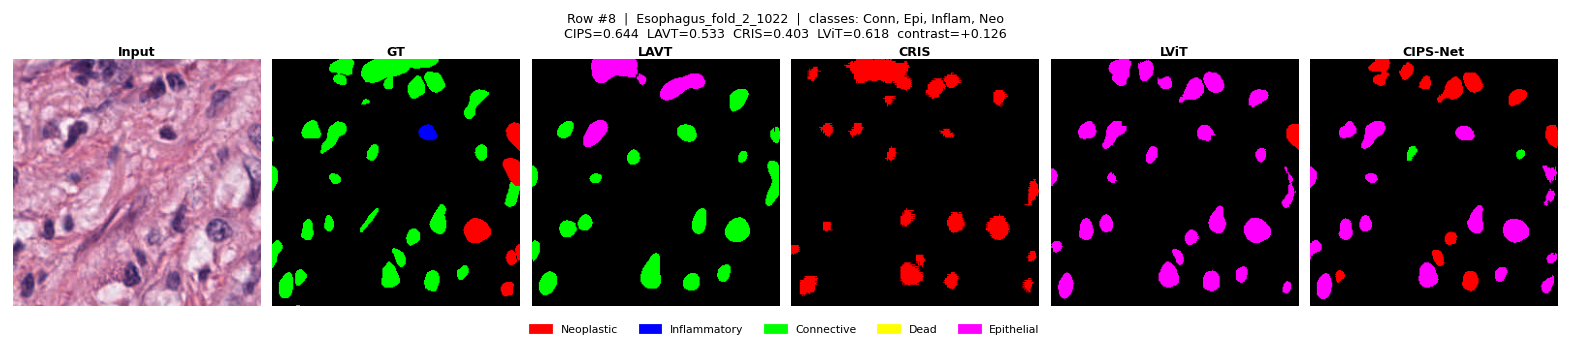

  → saved row_08_06_1_Esophagus_fold_2_1022.png


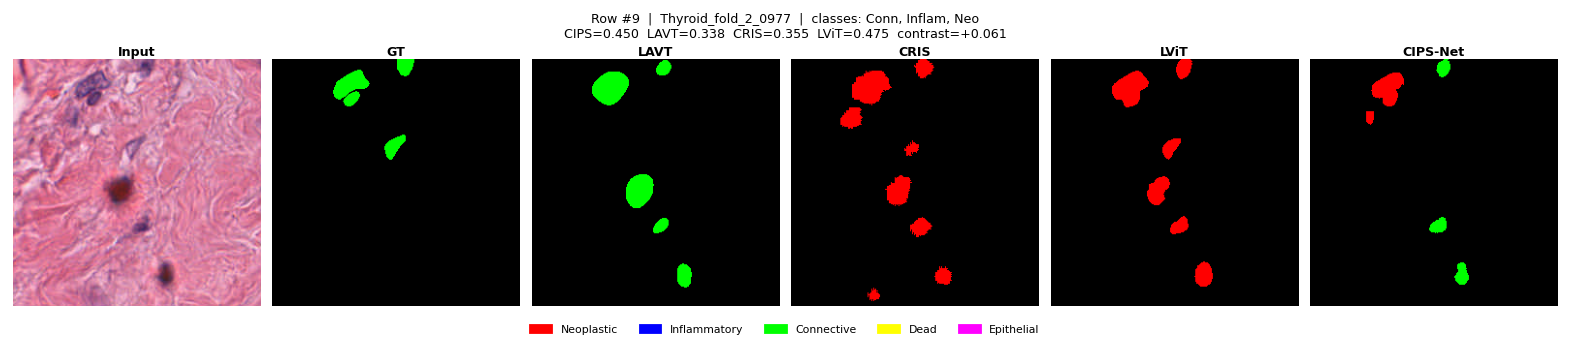

  → saved row_09_09_1_Thyroid_fold_2_0977.png


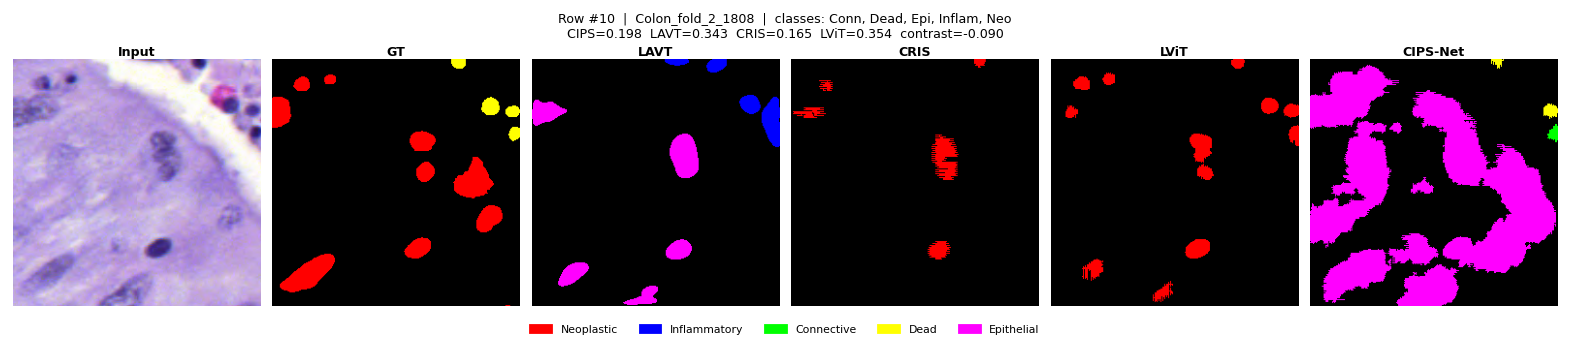

  → saved row_10_02_1_Colon_fold_2_1808.png


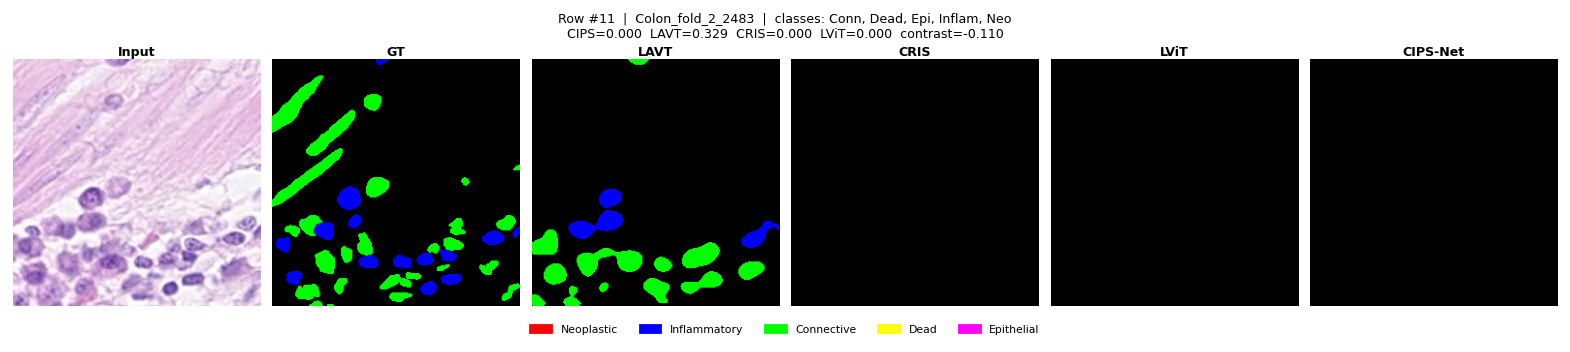

  → saved row_11_03_1_Colon_fold_2_2483.png


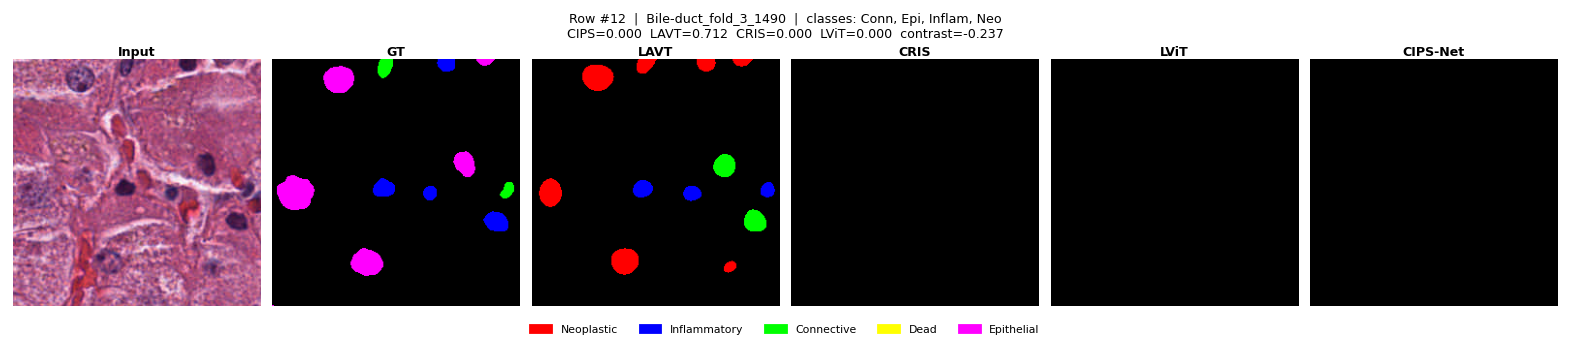

  → saved row_12_05_1_Bile-duct_fold_3_1490.png

All 12 individual rows saved to: vis_output/rows


In [13]:

# ── Show every candidate row individually so you can pick the best 3 ─────
# Each strip: Input | GT | LAVT | CRIS | LViT | CIPS-Net
# Title shows: rank, tissue, classes, and contrast score
# Saved individually to vis_output/rows/row_NN_<folder>.png

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image as PILImage
from pathlib import Path

ROWS_DIR = OUT_DIR / "rows"
ROWS_DIR.mkdir(exist_ok=True)

COLS = ["Input", "GT", "LAVT", "CRIS", "LViT", "CIPS-Net"]

def load_gt_combined(folder):
    rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for gf in sorted(folder.glob("gt_*.png")):
        arr = np.array(PILImage.open(gf).convert("RGB"))
        mask = np.any(arr > 10, axis=-1)
        rgb[mask] = arr[mask]
    return rgb

legend_patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS[i]) / 255, label=CLASS_NAMES[i])
    for i in range(1, 6)
]

# df_contrast is already sorted best→worst contrast
for rank_i, row in df_contrast.iterrows():
    folder_name = row["folder"]
    folder      = OUT_DIR / folder_name

    img_rgb  = np.array(PILImage.open(folder / "original.png").convert("RGB"))
    gt_rgb   = load_gt_combined(folder)
    lavt_rgb = np.array(PILImage.open(folder / "lavt_combined.png").convert("RGB"))
    cris_rgb = np.array(PILImage.open(folder / "cris_combined.png").convert("RGB"))
    lvit_rgb = np.array(PILImage.open(folder / "lvit_combined.png").convert("RGB"))
    cips_rgb = np.array(PILImage.open(folder / "static_combined.png").convert("RGB"))

    imgs = [img_rgb, gt_rgb, lavt_rgb, cris_rgb, lvit_rgb, cips_rgb]

    fig, axes = plt.subplots(1, 6, figsize=(12, 2.2), dpi=130)
    tissue_label = "_".join(folder_name.split("_")[2:])  # e.g. Prostate_fold_2_2239
    fig.suptitle(
        f"Row #{rank_i}  |  {tissue_label}  |  classes: {row['classes']}\n"
        f"CIPS={row['cips_iou']:.3f}  LAVT={row['lavt_iou']:.3f}  "
        f"CRIS={row['cris_iou']:.3f}  LViT={row['lvit_iou']:.3f}  "
        f"contrast={row['contrast']:+.3f}",
        fontsize=7, y=1.04,
    )

    for col_i, (img, title) in enumerate(zip(imgs, COLS)):
        ax = axes[col_i]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=7, fontweight="bold", pad=2)

    fig.legend(
        handles=legend_patches,
        loc="lower center", ncol=5, fontsize=6,
        frameon=False, bbox_to_anchor=(0.5, -0.12),
    )
    plt.tight_layout(pad=0.2)

    out_path = ROWS_DIR / f"row_{rank_i:02d}_{folder_name}.png"
    fig.savefig(str(out_path), dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  → saved {out_path.name}")

print(f"\nAll 12 individual rows saved to: {ROWS_DIR}")


In [9]:

# ── EXTENDED: Generate comparison strips for MANY more training images ────
# Goal: give you 40+ rows to browse and pick the best 3 for the paper
# We sample from fold_2 + fold_3 (training data), diverse tissues/class counts

import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image as PILImage
from pathlib import Path

EXT_DIR = OUT_DIR / "extended_rows"
EXT_DIR.mkdir(exist_ok=True)
print(f"Extended rows will be saved to: {EXT_DIR}\n")

# ── Sample more images from training folds ────────────────────────────────
# Already have cls_per_img from earlier (grouped by image_path with class_set)
# Exclude the 12 we already processed
existing = set(SELECTED_IMAGES)

# Get all training images with ≥2 classes (interesting for multi-class comparison)
candidates = cls_per_img[cls_per_img['n_gt'] >= 2].copy()
candidates = candidates[~candidates['image_path'].isin(existing)]
print(f"Total candidate images (≥2 classes, not in original 12): {len(candidates)}")

# Sample up to 40 more, stratified by tissue and class count
random.seed(42)
extra_images = []

# Group by (tissue, n_gt) and sample up to 5 per group
for (tissue, n_gt), grp in candidates.groupby(['tissue', 'n_gt']):
    pool = grp['image_path'].tolist()
    n_sample = min(5, len(pool))
    extra_images.extend(random.sample(pool, n_sample))

print(f"Sampled {len(extra_images)} additional images across tissues/class counts")

# ── Process each image: run CIPS-Net + baselines, save strip ──────────────
COLS = ["Input", "GT", "LAVT", "CRIS", "LViT", "CIPS-Net"]
legend_patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS[i]) / 255, label=CLASS_NAMES[i])
    for i in range(1, 6)
]

results = []
for idx, img_path in enumerate(extra_images):
    # Get static instruction
    static_row = df_static_tr[df_static_tr['image_path'] == img_path]
    if len(static_row) == 0:
        continue
    s_instr = static_row.iloc[0]['instruction']
    
    # Get class info
    cls_info = cls_per_img[cls_per_img['image_path'] == img_path].iloc[0]
    class_set = cls_info['class_set']
    n_gt = cls_info['n_gt']
    tissue = cls_info['tissue']
    
    # Load image
    img_rgb, img_t = load_image_tensor(img_path)
    
    # Run CIPS-Net
    cips_tmap = predict(img_t, s_instr)
    cips_rgb = type_map_to_rgb_combined(cips_tmap)
    
    # Run baselines
    lavt_tmap = predict_hv(baseline_models["LAVT"], "LAVT", img_t, s_instr)
    cris_tmap = predict_hv(baseline_models["CRIS"], "CRIS", img_t, s_instr)
    lvit_tmap = predict_hv(baseline_models["LViT"], "LViT", img_t, s_instr)
    
    lavt_rgb = type_map_to_rgb_combined(lavt_tmap)
    cris_rgb = type_map_to_rgb_combined(cris_tmap)
    lvit_rgb = type_map_to_rgb_combined(lvit_tmap)
    
    # Build GT combined from mask files
    gt_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for cls_name in class_set:
        gt_cls = load_gt_class_mask(img_path, cls_name)
        if gt_cls is not None:
            mask = np.any(gt_cls > 10, axis=-1)
            gt_rgb[mask] = gt_cls[mask]
    
    # Compute IoUs
    def binary_iou(gt, pred):
        g = np.any(gt > 10, axis=-1)
        p = np.any(pred > 10, axis=-1)
        inter = (g & p).sum()
        union = (g | p).sum()
        return inter / union if union > 0 else 0.0
    
    cips_iou = binary_iou(gt_rgb, cips_rgb)
    lavt_iou = binary_iou(gt_rgb, lavt_rgb)
    cris_iou = binary_iou(gt_rgb, cris_rgb)
    lvit_iou = binary_iou(gt_rgb, lvit_rgb)
    mean_base = (lavt_iou + cris_iou + lvit_iou) / 3
    contrast = cips_iou - mean_base
    
    results.append({
        'idx': idx + 1,
        'image_path': img_path,
        'tissue': tissue,
        'n_gt': n_gt,
        'classes': sorted([c.replace('Connective_Soft_tissue','Conn').replace('Inflammatory','Inflam')[:4] for c in class_set]),
        'cips_iou': cips_iou,
        'lavt_iou': lavt_iou,
        'cris_iou': cris_iou,
        'lvit_iou': lvit_iou,
        'contrast': contrast,
    })
    
    # Save comparison strip
    imgs = [img_rgb, gt_rgb, lavt_rgb, cris_rgb, lvit_rgb, cips_rgb]
    
    fig, axes = plt.subplots(1, 6, figsize=(12, 2.2), dpi=130)
    cls_str = ",".join(sorted([c[:4] for c in class_set]))
    fig.suptitle(
        f"#{idx+1}  |  {tissue}  |  {n_gt}-class: {cls_str}\n"
        f"CIPS={cips_iou:.2f}  LAVT={lavt_iou:.2f}  CRIS={cris_iou:.2f}  LViT={lvit_iou:.2f}  "
        f"contrast={contrast:+.2f}",
        fontsize=7, y=1.04,
    )
    
    for col_i, (img, title) in enumerate(zip(imgs, COLS)):
        ax = axes[col_i]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=7, fontweight="bold", pad=2)
    
    fig.legend(
        handles=legend_patches,
        loc="lower center", ncol=5, fontsize=6,
        frameon=False, bbox_to_anchor=(0.5, -0.12),
    )
    plt.tight_layout(pad=0.2)
    
    safe_name = img_path.replace('_img.png', '').replace('/', '_')
    out_path = EXT_DIR / f"ext_{idx+1:02d}_{tissue}_{n_gt}cls_{safe_name}.png"
    fig.savefig(str(out_path), dpi=130, bbox_inches="tight")
    plt.close(fig)  # Don't display all, just save
    
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx+1}/{len(extra_images)}...")

print(f"\n✓ Generated {len(results)} extended comparison strips!")

# ── Sort by contrast and show ranking ─────────────────────────────────────
df_ext = pd.DataFrame(results).sort_values('contrast', ascending=False).reset_index(drop=True)
df_ext.index += 1
print("\n" + "="*90)
print("EXTENDED RANKING (sorted by contrast = CIPS best, baselines worst):")
print("="*90)
print(df_ext[['idx','tissue','n_gt','classes','cips_iou','lavt_iou','cris_iou','lvit_iou','contrast']].head(30).to_string())
print(f"\nAll {len(results)} strips saved to: {EXT_DIR}")
print("\nBrowse the folder and tell me which row numbers you want for the final figure!")


Extended rows will be saved to: vis_output/extended_rows

Total candidate images (≥2 classes, not in original 12): 839
Sampled 150 additional images across tissues/class counts
  Processed 10/150...
  Processed 20/150...
  Processed 30/150...
  Processed 40/150...
  Processed 50/150...
  Processed 60/150...
  Processed 70/150...
  Processed 80/150...
  Processed 90/150...
  Processed 100/150...
  Processed 110/150...
  Processed 120/150...
  Processed 130/150...
  Processed 140/150...
  Processed 150/150...

✓ Generated 150 extended comparison strips!

EXTENDED RANKING (sorted by contrast = CIPS best, baselines worst):
    idx      tissue  n_gt                         classes  cips_iou  lavt_iou  cris_iou  lvit_iou  contrast
1   150     Thyroid     4        [Conn, Dead, Infl, Neop]  0.730942  0.485294  0.000000  0.327842  0.459896
2    87        Lung     3              [Conn, Infl, Neop]  0.578483  0.285597  0.137672  0.142195  0.389995
3   109  Pancreatic     4        [Conn, Epit, Inf

In [11]:

# ── Recompute rankings by per-class IoU (proxy for mPQ) ──────────────────
# mPQ = mean Panoptic Quality across classes
# We approximate with mean per-class IoU (semantic overlap per class)

import pandas as pd
import numpy as np
from PIL import Image as PILImage

def compute_per_class_iou(gt_rgb, pred_rgb):
    """
    Compute IoU for each class separately, then return mean.
    This is a better proxy for mPQ than binary IoU.
    """
    class_ious = []
    for tid, color in CLASS_COLORS.items():
        if tid == 0:  # skip background
            continue
        # Extract class masks
        gt_mask = np.all(gt_rgb == color, axis=-1)
        pred_mask = np.all(pred_rgb == color, axis=-1)
        
        # Only count if class exists in GT
        if gt_mask.sum() > 0:
            inter = (gt_mask & pred_mask).sum()
            union = (gt_mask | pred_mask).sum()
            iou = inter / union if union > 0 else 0.0
            class_ious.append(iou)
    
    return np.mean(class_ious) if class_ious else 0.0

# ── Recompute for all extended results ────────────────────────────────────
print("Recomputing per-class IoU (mPQ proxy) for all 150 images...\n")

mpq_results = []
for idx, img_path in enumerate(extra_images):
    # Get static instruction
    static_row = df_static_tr[df_static_tr['image_path'] == img_path]
    if len(static_row) == 0:
        continue
    s_instr = static_row.iloc[0]['instruction']
    
    # Get class info
    cls_info = cls_per_img[cls_per_img['image_path'] == img_path].iloc[0]
    class_set = cls_info['class_set']
    n_gt = cls_info['n_gt']
    tissue = cls_info['tissue']
    
    # Load image
    img_rgb, img_t = load_image_tensor(img_path)
    
    # Run CIPS-Net
    cips_tmap = predict(img_t, s_instr)
    cips_rgb = type_map_to_rgb_combined(cips_tmap)
    
    # Run baselines
    lavt_tmap = predict_hv(baseline_models["LAVT"], "LAVT", img_t, s_instr)
    cris_tmap = predict_hv(baseline_models["CRIS"], "CRIS", img_t, s_instr)
    lvit_tmap = predict_hv(baseline_models["LViT"], "LViT", img_t, s_instr)
    
    lavt_rgb = type_map_to_rgb_combined(lavt_tmap)
    cris_rgb = type_map_to_rgb_combined(cris_tmap)
    lvit_rgb = type_map_to_rgb_combined(lvit_tmap)
    
    # Build GT combined from mask files
    gt_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for cls_name in class_set:
        gt_cls = load_gt_class_mask(img_path, cls_name)
        if gt_cls is not None:
            mask = np.any(gt_cls > 10, axis=-1)
            gt_rgb[mask] = gt_cls[mask]
    
    # Compute per-class IoU (mPQ proxy)
    cips_mpq = compute_per_class_iou(gt_rgb, cips_rgb)
    lavt_mpq = compute_per_class_iou(gt_rgb, lavt_rgb)
    cris_mpq = compute_per_class_iou(gt_rgb, cris_rgb)
    lvit_mpq = compute_per_class_iou(gt_rgb, lvit_rgb)
    
    mean_base_mpq = (lavt_mpq + cris_mpq + lvit_mpq) / 3
    contrast_mpq = cips_mpq - mean_base_mpq
    
    # Get the saved filename
    safe_name = img_path.replace('_img.png', '').replace('/', '_')
    filename = f"ext_{idx+1:02d}_{tissue}_{n_gt}cls_{safe_name}.png"
    
    mpq_results.append({
        'idx': idx + 1,
        'filename': filename,
        'image_path': img_path,
        'tissue': tissue,
        'n_gt': n_gt,
        'classes': ", ".join(sorted([c.replace('Connective_Soft_tissue','Conn').replace('Inflammatory','Inflam') for c in class_set])),
        'cips_mpq': round(cips_mpq * 100, 1),  # as percentage
        'lavt_mpq': round(lavt_mpq * 100, 1),
        'cris_mpq': round(cris_mpq * 100, 1),
        'lvit_mpq': round(lvit_mpq * 100, 1),
        'mean_base_mpq': round(mean_base_mpq * 100, 1),
        'contrast': round(contrast_mpq * 100, 1),
    })
    
    if (idx + 1) % 25 == 0:
        print(f"  Processed {idx+1}/{len(extra_images)}...")

print(f"\n✓ Computed mPQ for {len(mpq_results)} images!")

# ── Create DataFrame sorted by CIPS-Net mPQ (best CIPS results first) ─────
df_mpq = pd.DataFrame(mpq_results)

# Sort by CIPS-Net mPQ (descending) - best CIPS-Net results first
df_mpq_by_cips = df_mpq.sort_values('cips_mpq', ascending=False).reset_index(drop=True)
df_mpq_by_cips.index += 1

print("\n" + "="*120)
print("RANKING BY CIPS-Net mPQ (%) — Best CIPS-Net results first:")
print("="*120)
print(df_mpq_by_cips[['idx','tissue','n_gt','classes','cips_mpq','lavt_mpq','cris_mpq','lvit_mpq','contrast','filename']].head(40).to_string())

# Also show sorted by contrast (CIPS best AND baselines worst)
df_mpq_by_contrast = df_mpq.sort_values('contrast', ascending=False).reset_index(drop=True)
df_mpq_by_contrast.index += 1

print("\n" + "="*120)
print("RANKING BY CONTRAST (%) — CIPS-Net best AND baselines worst:")
print("="*120)
print(df_mpq_by_contrast[['idx','tissue','n_gt','classes','cips_mpq','lavt_mpq','cris_mpq','lvit_mpq','contrast','filename']].head(40).to_string())

# Save rankings to CSV for easy browsing
df_mpq_by_cips.to_csv(EXT_DIR / "ranking_by_cips_mpq.csv", index=False)
df_mpq_by_contrast.to_csv(EXT_DIR / "ranking_by_contrast.csv", index=False)
print(f"\n✓ Rankings saved to:")
print(f"   {EXT_DIR}/ranking_by_cips_mpq.csv")
print(f"   {EXT_DIR}/ranking_by_contrast.csv")
print(f"\nBrowse the folder and pick row numbers (idx column) for the final figure!")


Recomputing per-class IoU (mPQ proxy) for all 150 images...

  Processed 25/150...
  Processed 50/150...
  Processed 75/150...
  Processed 100/150...
  Processed 125/150...
  Processed 150/150...

✓ Computed mPQ for 150 images!

RANKING BY CIPS-Net mPQ (%) — Best CIPS-Net results first:
    idx      tissue  n_gt                                     classes  cips_mpq  lavt_mpq  cris_mpq  lvit_mpq  contrast                                              filename
1    47       Colon     2                            Conn, Epithelial      83.7      79.1      14.7      38.3      39.6             ext_47_Colon_2cls_1_Colon_fold_2_1752.png
2   105  Pancreatic     3                    Conn, Inflam, Neoplastic      79.9      59.3       9.4       0.0      57.0  ext_105_Pancreatic_3cls_1_Pancreatic_fold_2_2203.png
3   125    Prostate     4        Conn, Epithelial, Inflam, Neoplastic      72.0       0.0      57.1       9.1      49.9      ext_125_Prostate_4cls_1_Prostate_fold_2_2244.png
4    61       Co

Displaying 10 shortlisted images:



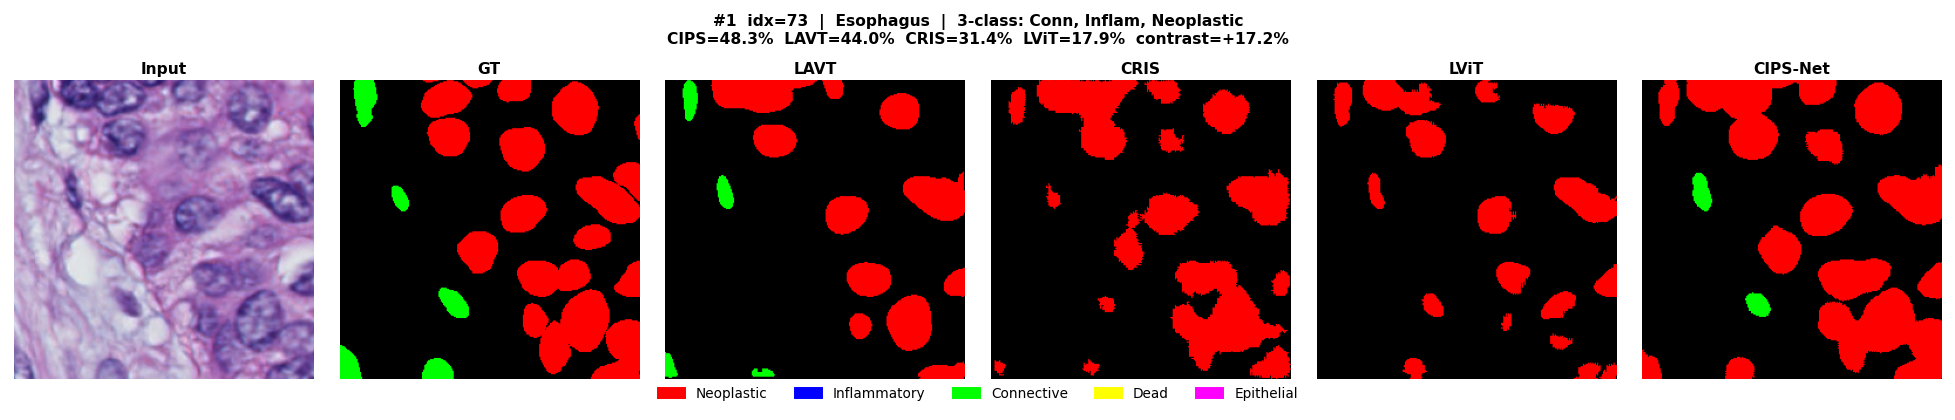

  ↑ idx=73 | Esophagus | Conn, Inflam, Neoplastic



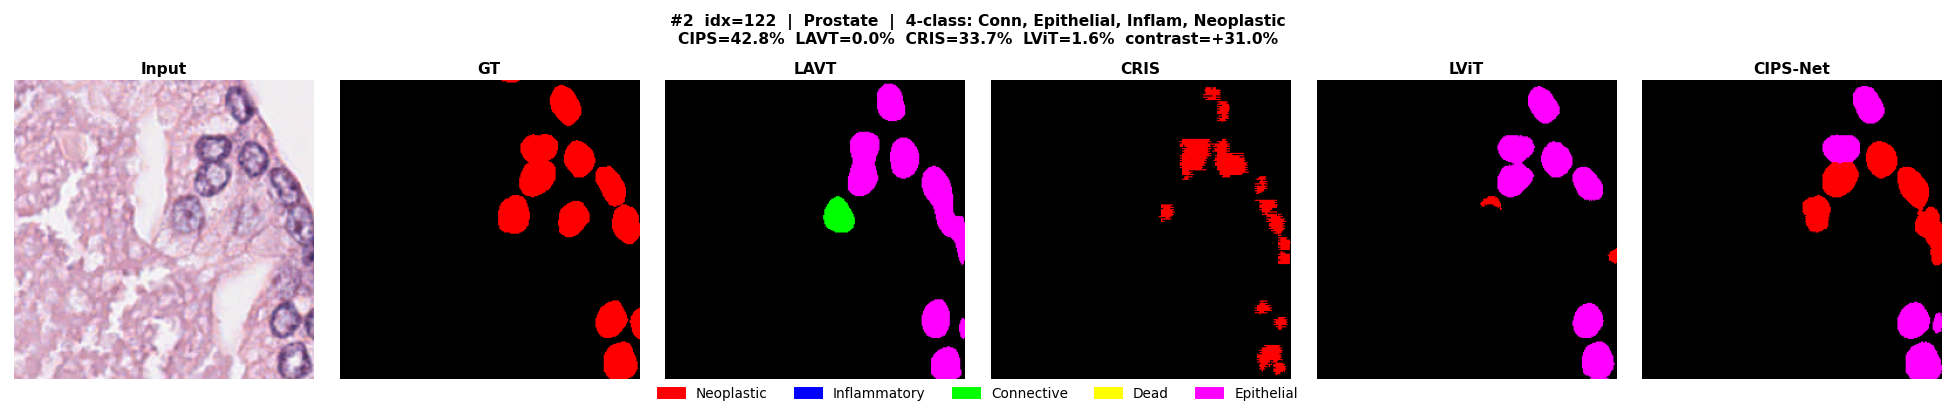

  ↑ idx=122 | Prostate | Conn, Epithelial, Inflam, Neoplastic



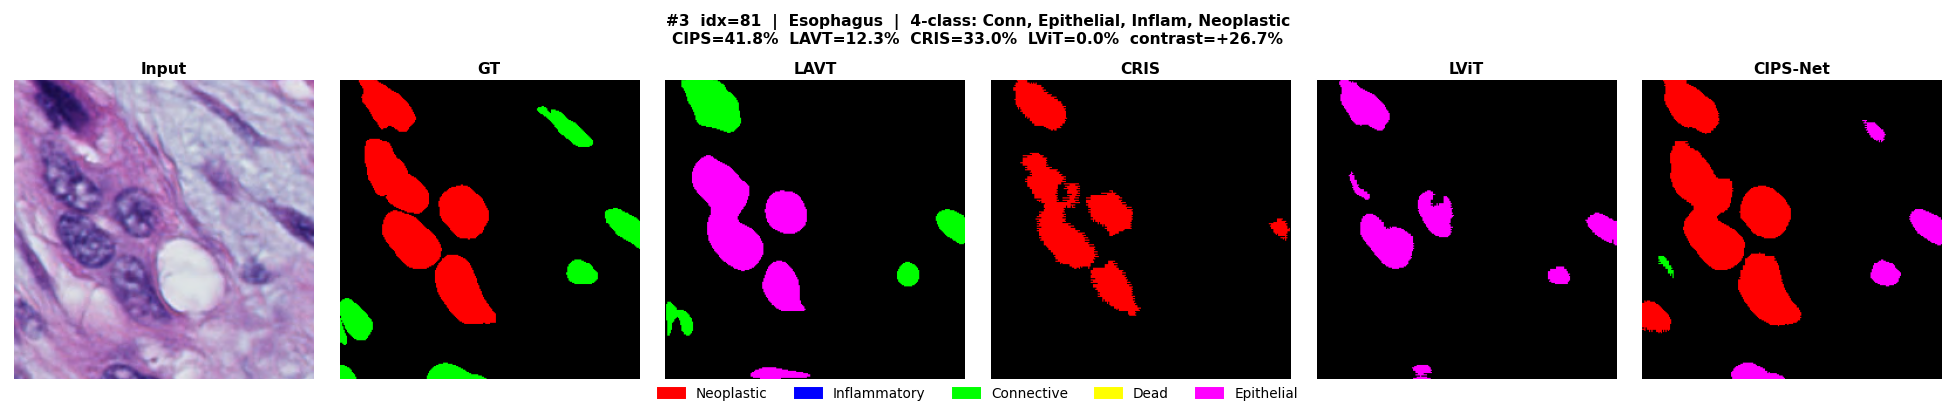

  ↑ idx=81 | Esophagus | Conn, Epithelial, Inflam, Neoplastic



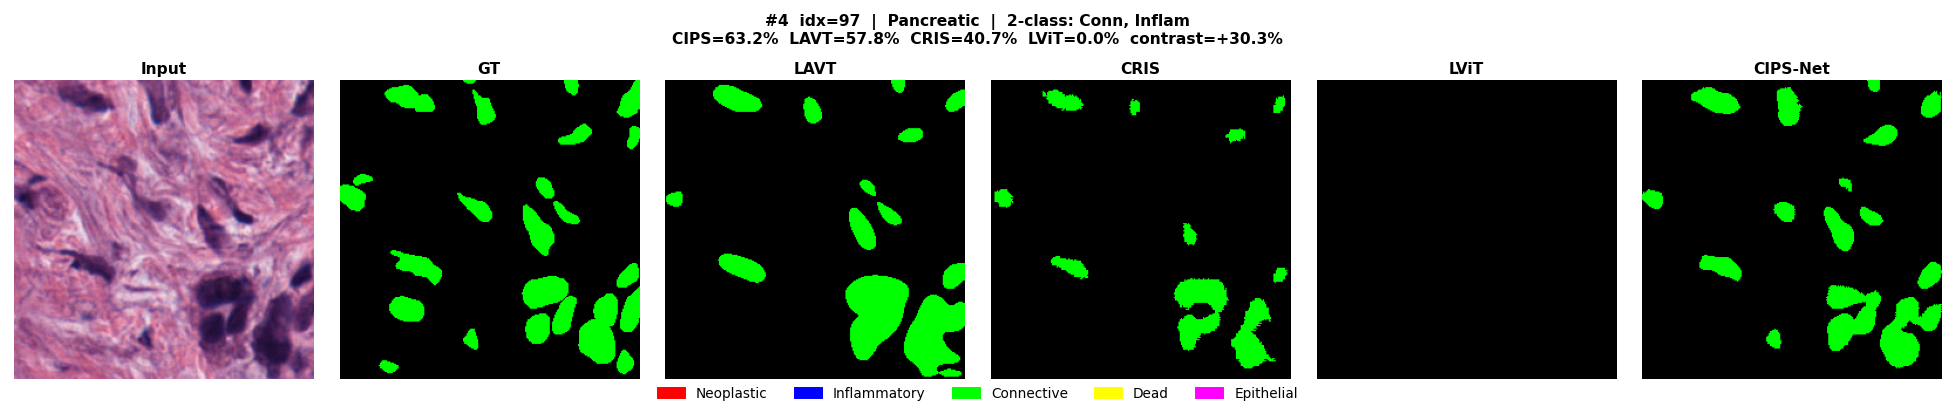

  ↑ idx=97 | Pancreatic | Conn, Inflam



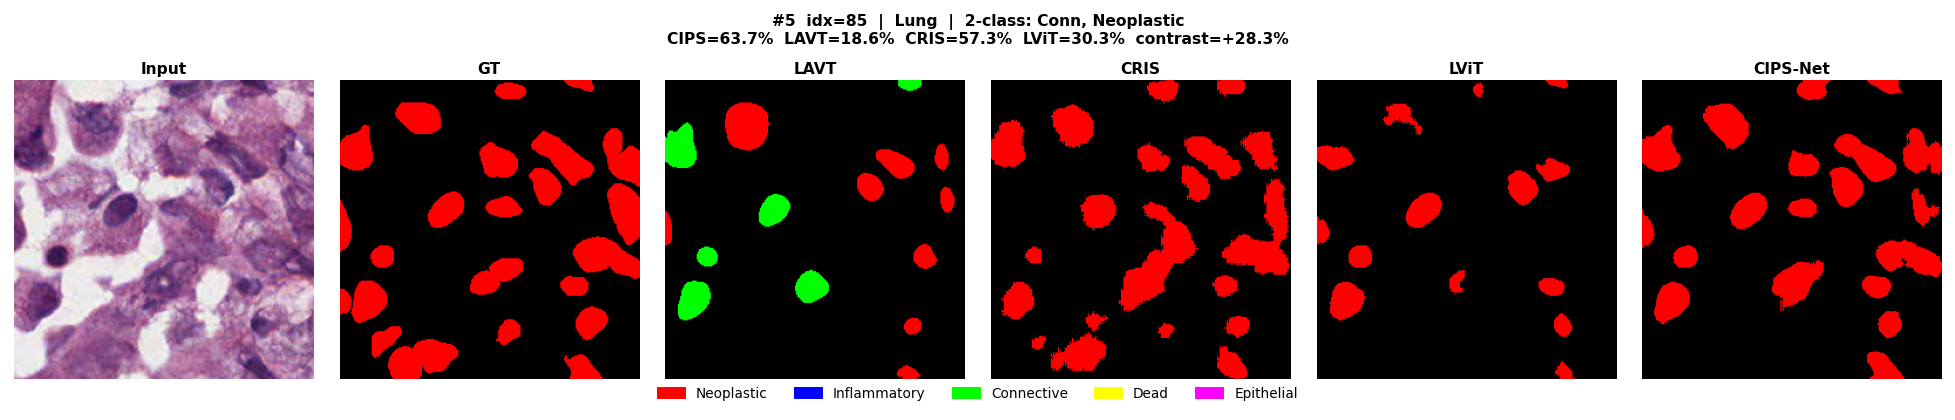

  ↑ idx=85 | Lung | Conn, Neoplastic



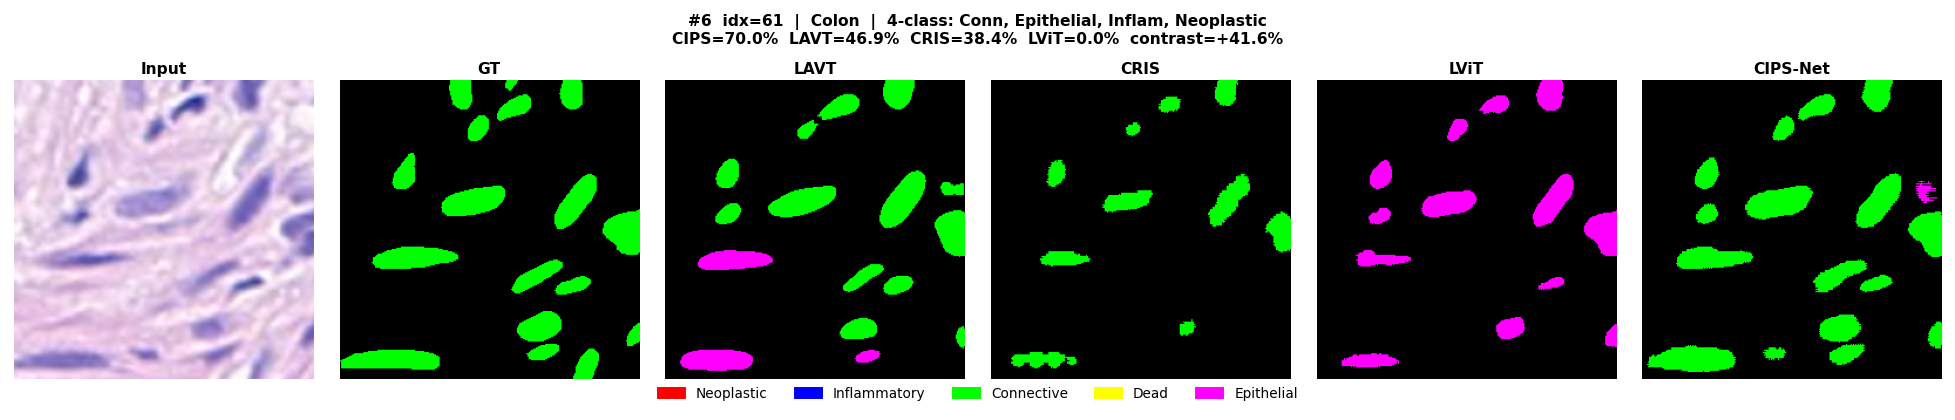

  ↑ idx=61 | Colon | Conn, Epithelial, Inflam, Neoplastic



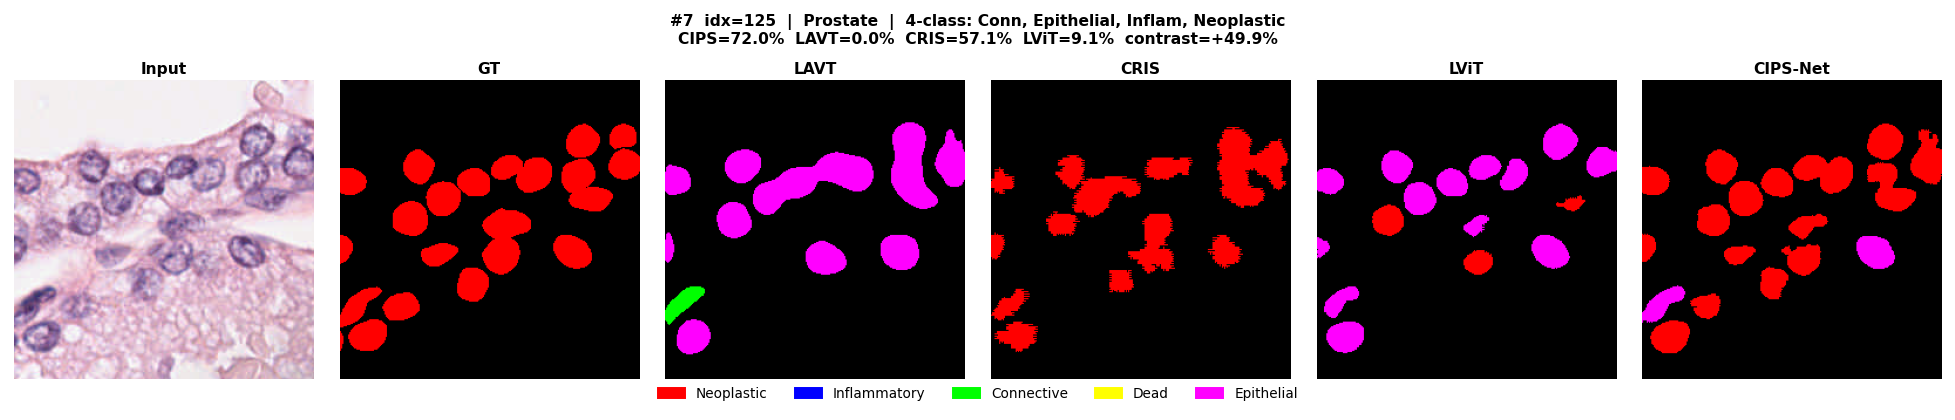

  ↑ idx=125 | Prostate | Conn, Epithelial, Inflam, Neoplastic



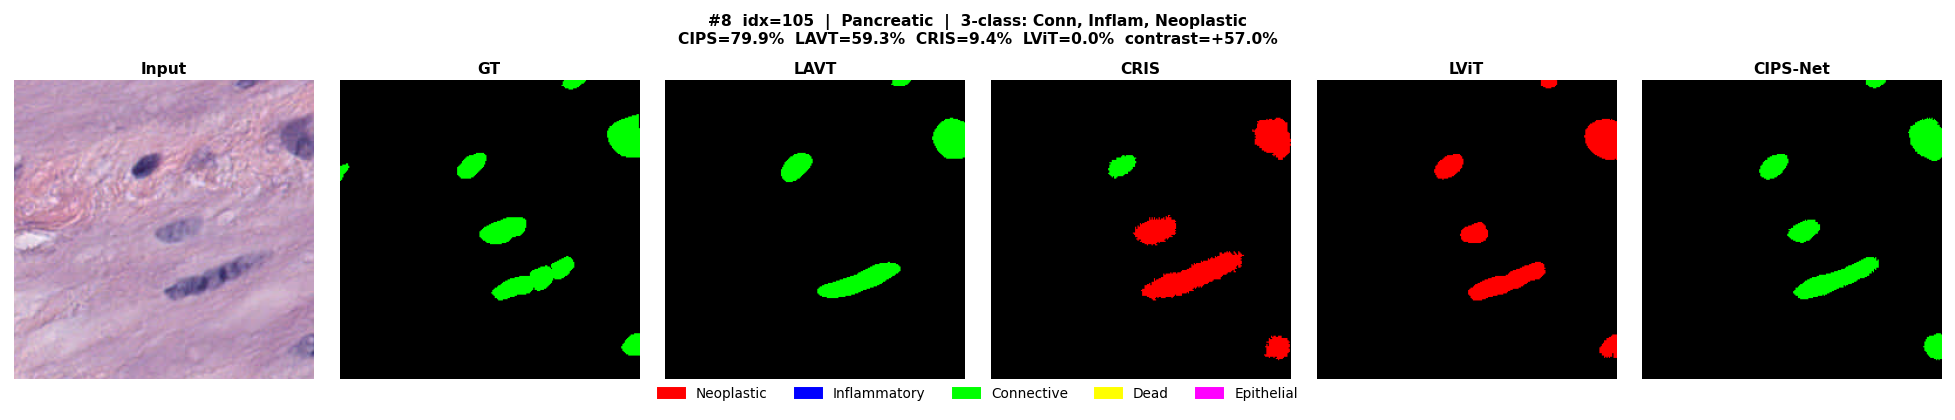

  ↑ idx=105 | Pancreatic | Conn, Inflam, Neoplastic



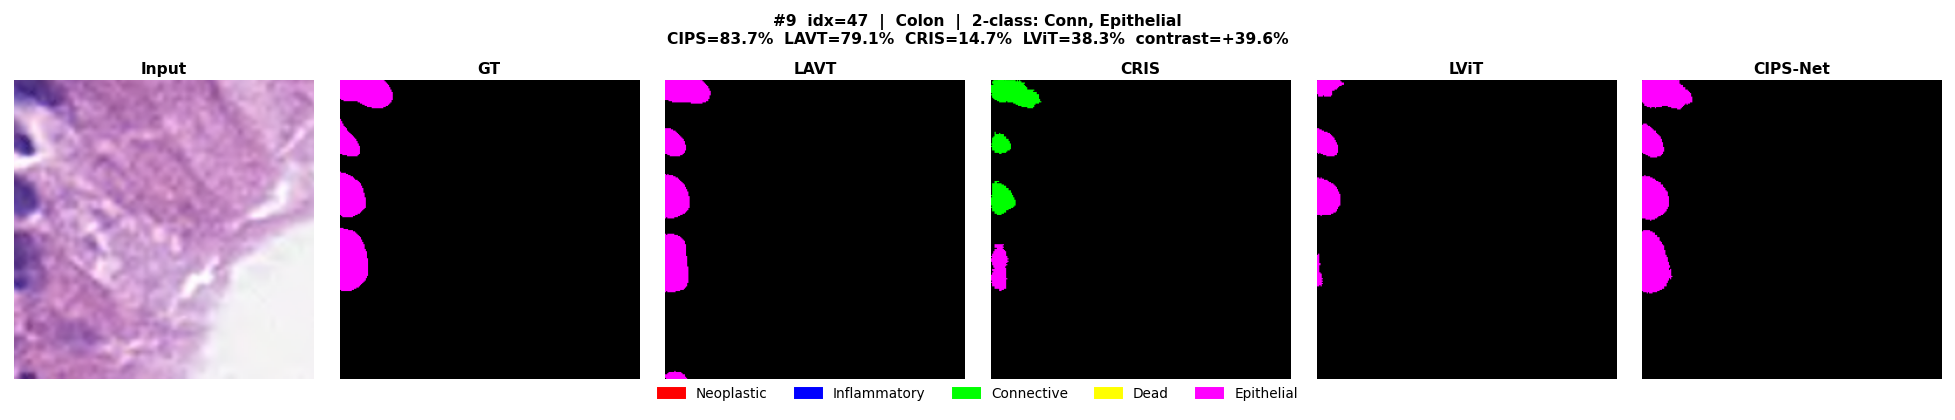

  ↑ idx=47 | Colon | Conn, Epithelial



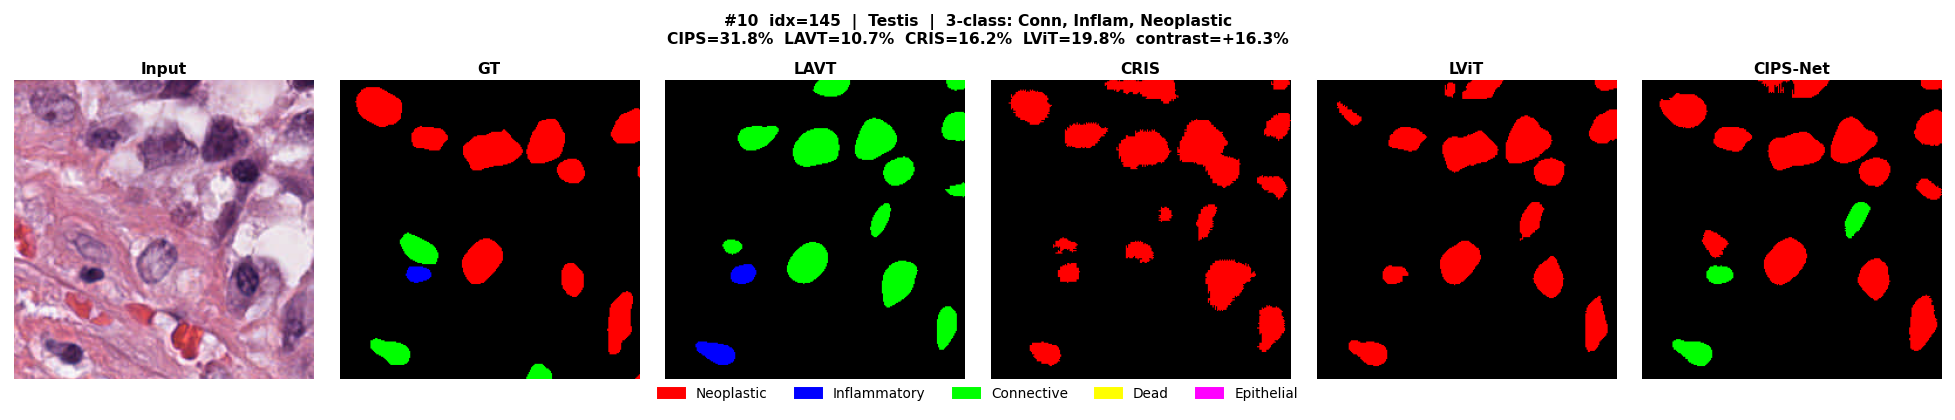

  ↑ idx=145 | Testis | Conn, Inflam, Neoplastic

Pick your final 3-4 idx values and I'll create the combined paper figure!


In [12]:

# ── Display your shortlisted images for final selection ───────────────────
# Selected idx values: 73, 122, 81, 97, 85, 61, 125, 105, 47, 145

SHORTLIST = [73, 122, 81, 97, 85, 61, 125, 105, 47, 145]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image as PILImage

COLS = ["Input", "GT", "LAVT", "CRIS", "LViT", "CIPS-Net"]
legend_patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS[i]) / 255, label=CLASS_NAMES[i])
    for i in range(1, 6)
]

print(f"Displaying {len(SHORTLIST)} shortlisted images:\n")

for rank, sel_idx in enumerate(SHORTLIST, 1):
    # Find the row in df_mpq
    row = df_mpq[df_mpq['idx'] == sel_idx]
    if len(row) == 0:
        print(f"  #{sel_idx} not found!")
        continue
    row = row.iloc[0]
    
    img_path = row['image_path']
    tissue = row['tissue']
    n_gt = row['n_gt']
    classes = row['classes']
    
    # Load image
    img_rgb, img_t = load_image_tensor(img_path)
    
    # Get static instruction
    static_row = df_static_tr[df_static_tr['image_path'] == img_path]
    s_instr = static_row.iloc[0]['instruction']
    
    # Get class info for GT
    cls_info = cls_per_img[cls_per_img['image_path'] == img_path].iloc[0]
    class_set = cls_info['class_set']
    
    # Run models
    cips_tmap = predict(img_t, s_instr)
    cips_rgb = type_map_to_rgb_combined(cips_tmap)
    
    lavt_tmap = predict_hv(baseline_models["LAVT"], "LAVT", img_t, s_instr)
    cris_tmap = predict_hv(baseline_models["CRIS"], "CRIS", img_t, s_instr)
    lvit_tmap = predict_hv(baseline_models["LViT"], "LViT", img_t, s_instr)
    
    lavt_rgb = type_map_to_rgb_combined(lavt_tmap)
    cris_rgb = type_map_to_rgb_combined(cris_tmap)
    lvit_rgb = type_map_to_rgb_combined(lvit_tmap)
    
    # Build GT
    gt_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for cls_name in class_set:
        gt_cls = load_gt_class_mask(img_path, cls_name)
        if gt_cls is not None:
            mask = np.any(gt_cls > 10, axis=-1)
            gt_rgb[mask] = gt_cls[mask]
    
    # Plot
    imgs = [img_rgb, gt_rgb, lavt_rgb, cris_rgb, lvit_rgb, cips_rgb]
    
    fig, axes = plt.subplots(1, 6, figsize=(14, 2.5), dpi=140)
    fig.suptitle(
        f"#{rank}  idx={sel_idx}  |  {tissue}  |  {n_gt}-class: {classes}\n"
        f"CIPS={row['cips_mpq']:.1f}%  LAVT={row['lavt_mpq']:.1f}%  "
        f"CRIS={row['cris_mpq']:.1f}%  LViT={row['lvit_mpq']:.1f}%  "
        f"contrast={row['contrast']:+.1f}%",
        fontsize=8, fontweight='bold', y=1.06,
    )
    
    for col_i, (img, title) in enumerate(zip(imgs, COLS)):
        ax = axes[col_i]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=8, fontweight="bold", pad=3)
    
    fig.legend(
        handles=legend_patches,
        loc="lower center", ncol=5, fontsize=7,
        frameon=False, bbox_to_anchor=(0.5, -0.08),
    )
    plt.tight_layout(pad=0.3)
    plt.show()
    print(f"  ↑ idx={sel_idx} | {tissue} | {classes}")
    print()

print("="*80)
print("Pick your final 3-4 idx values and I'll create the combined paper figure!")


nkhil

  Processed idx=125 (Prostate)
  Processed idx=85 (Lung)
  Processed idx=47 (Colon)

✓ Saved: vis_output/paper_qualitative_figure.png
✓ Saved: vis_output/paper_qualitative_figure.pdf
✓ Saved raw: vis_output/paper_qualitative_raw.png


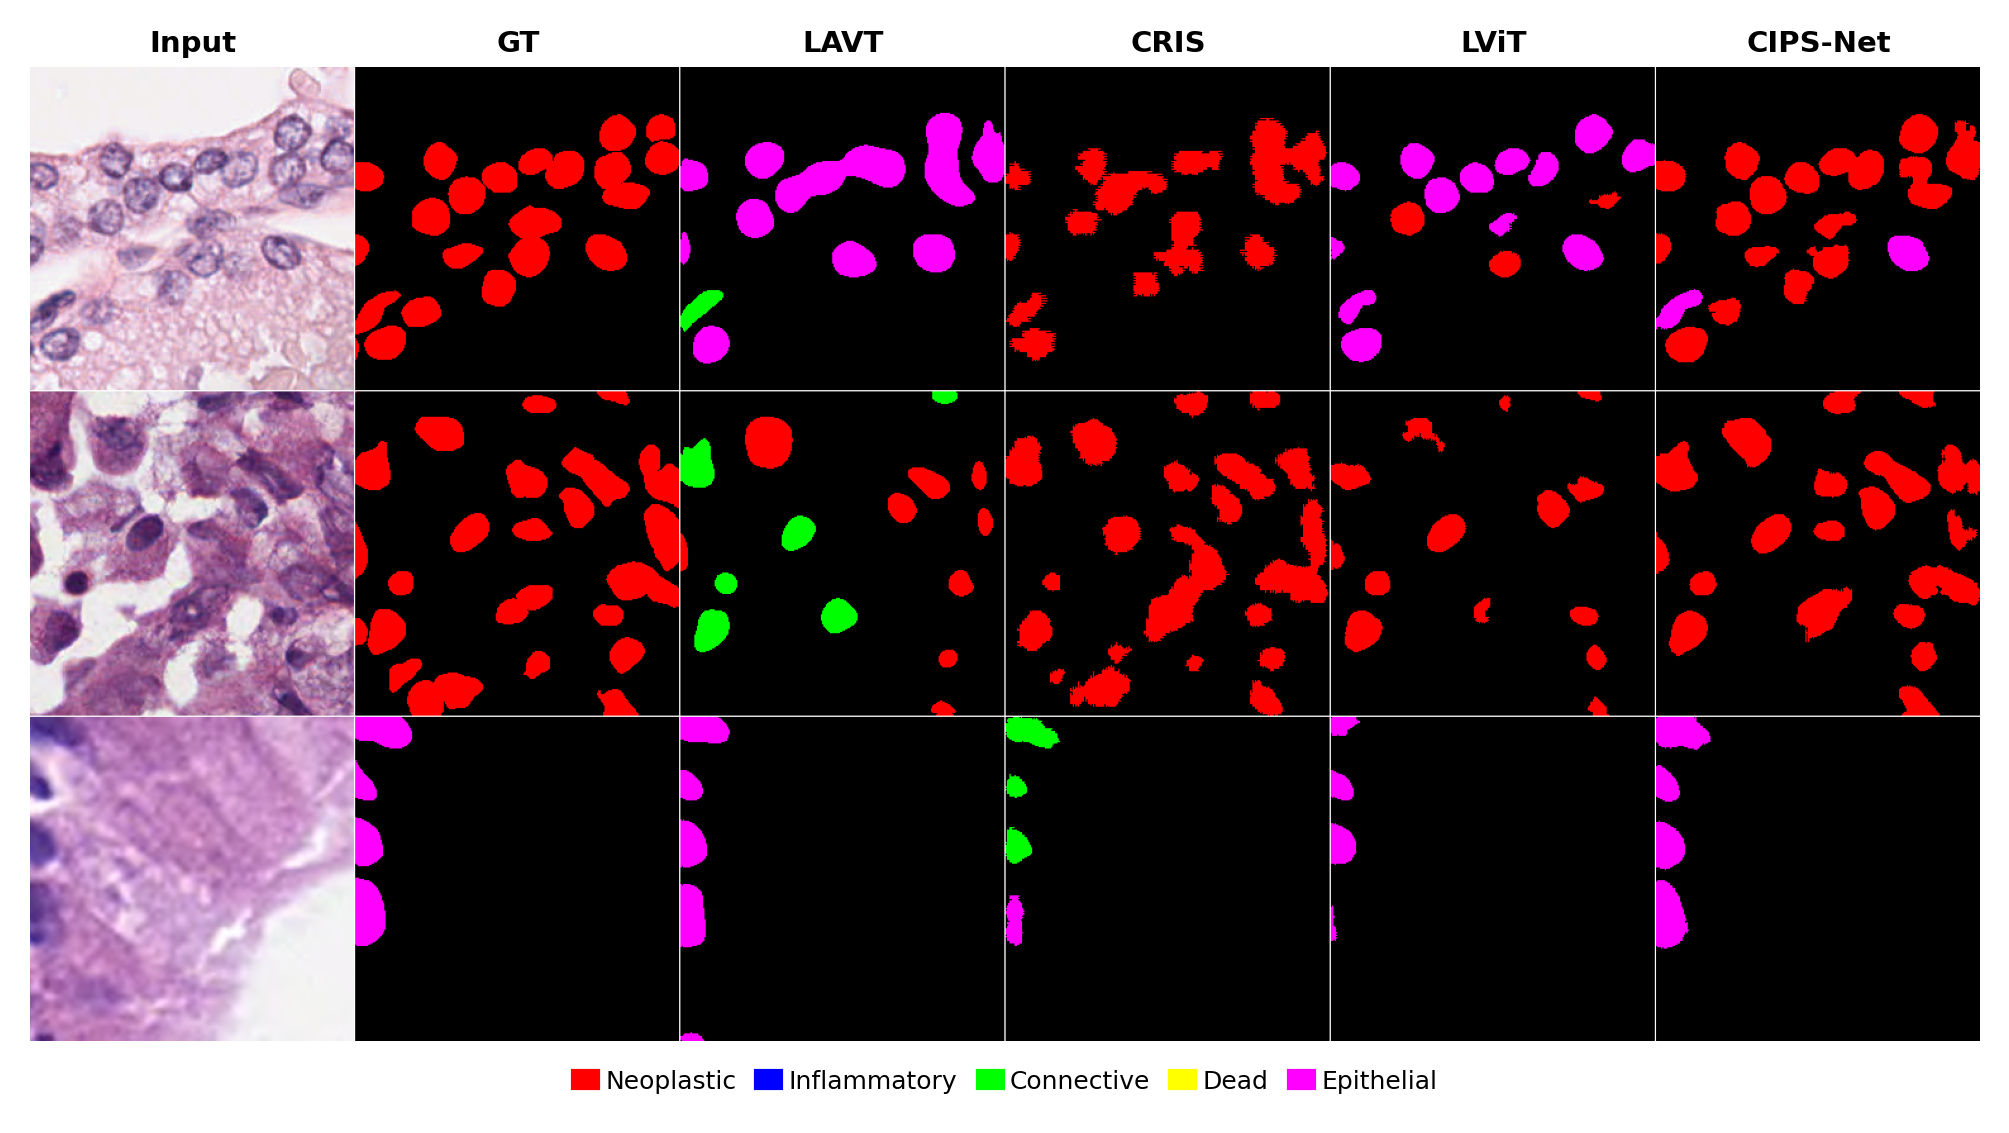


Figure details:
  Row 125: Prostate | 4-class | CIPS=72.0% | contrast=+49.9%
  Row 85: Lung | 2-class | CIPS=63.7% | contrast=+28.3%
  Row 47: Colon | 2-class | CIPS=83.7% | contrast=+39.6%


In [12]:
# ── Final Paper Figure: 3 rows × 6 cols, ultra-compact ────────────────────
# Selected: idx=125 (Prostate), idx=85 (Lung), idx=47 (Colon)

FINAL_IDX = [125, 85, 47]
COLS = ["Input", "GT", "LAVT", "CRIS", "LViT", "CIPS-Net"]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image as PILImage

# Collect all row data
rows_data = []
for sel_idx in FINAL_IDX:
    row = df_mpq[df_mpq['idx'] == sel_idx].iloc[0]
    img_path = row['image_path']
    
    # Load image
    img_rgb, img_t = load_image_tensor(img_path)
    
    # Get instruction
    static_row = df_static_tr[df_static_tr['image_path'] == img_path]
    s_instr = static_row.iloc[0]['instruction']
    
    # Get class info for GT
    cls_info = cls_per_img[cls_per_img['image_path'] == img_path].iloc[0]
    class_set = cls_info['class_set']
    
    # Run models
    cips_rgb = type_map_to_rgb_combined(predict(img_t, s_instr))
    lavt_rgb = type_map_to_rgb_combined(predict_hv(baseline_models["LAVT"], "LAVT", img_t, s_instr))
    cris_rgb = type_map_to_rgb_combined(predict_hv(baseline_models["CRIS"], "CRIS", img_t, s_instr))
    lvit_rgb = type_map_to_rgb_combined(predict_hv(baseline_models["LViT"], "LViT", img_t, s_instr))
    
    # Build GT
    gt_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for cls_name in class_set:
        gt_cls = load_gt_class_mask(img_path, cls_name)
        if gt_cls is not None:
            mask = np.any(gt_cls > 10, axis=-1)
            gt_rgb[mask] = gt_cls[mask]
    
    rows_data.append({
        'idx': sel_idx,
        'tissue': row['tissue'],
        'imgs': [img_rgb, gt_rgb, lavt_rgb, cris_rgb, lvit_rgb, cips_rgb],
    })
    print(f"  Processed idx={sel_idx} ({row['tissue']})")

# ── Create ultra-compact figure with minimal gaps ─────────────────────────
# Stitch images directly with 1px white separator

IMG_SIZE = 256
GAP = 1  # 1 pixel white line between images
N_ROWS, N_COLS = 3, 6

# Calculate canvas size
canvas_w = N_COLS * IMG_SIZE + (N_COLS - 1) * GAP
canvas_h = N_ROWS * IMG_SIZE + (N_ROWS - 1) * GAP

# Create white canvas
canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255

# Place images
for row_i, rd in enumerate(rows_data):
    for col_i, img in enumerate(rd['imgs']):
        y = row_i * (IMG_SIZE + GAP)
        x = col_i * (IMG_SIZE + GAP)
        # Resize if needed
        if img.shape[0] != IMG_SIZE or img.shape[1] != IMG_SIZE:
            img = np.array(PILImage.fromarray(img).resize((IMG_SIZE, IMG_SIZE)))
        canvas[y:y+IMG_SIZE, x:x+IMG_SIZE] = img

# Save the stitched image
from PIL import Image as PILImage
stitched_img = PILImage.fromarray(canvas)

# Now create figure with column headers and legend only
fig, ax = plt.subplots(figsize=(6.5, 3.6), dpi=300)
ax.imshow(canvas)
ax.axis('off')

# Add column titles at top
for col_i, title in enumerate(COLS):
    x_center = col_i * (IMG_SIZE + GAP) + IMG_SIZE / 2
    ax.text(x_center, -8, title, ha='center', va='bottom', fontsize=7, fontweight='bold')

# Compact legend at bottom
legend_patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS[i])/255, label=CLASS_NAMES[i])
    for i in [1, 2, 3, 4, 5]
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,
    fontsize=6,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    handlelength=1.0,
    handletextpad=0.3,
    columnspacing=0.8,
)

plt.subplots_adjust(left=0, right=1, top=0.96, bottom=0.04)

# Save
out_path = Path("vis_output/paper_qualitative_figure.png")
fig.savefig(str(out_path), dpi=300, bbox_inches='tight', pad_inches=0.01)
print(f"\n✓ Saved: {out_path}")

pdf_path = Path("vis_output/paper_qualitative_figure.pdf")
fig.savefig(str(pdf_path), bbox_inches='tight', pad_inches=0.01)
print(f"✓ Saved: {pdf_path}")

# Also save raw stitched image without any matplotlib overhead
raw_path = Path("vis_output/paper_qualitative_raw.png")
stitched_img.save(str(raw_path))
print(f"✓ Saved raw: {raw_path}")

plt.show()

print("\n" + "="*60)
print("Figure details:")
for rd in rows_data:
    row = df_mpq[df_mpq['idx'] == rd['idx']].iloc[0]
    print(f"  Row {rd['idx']}: {rd['tissue']} | {row['n_gt']}-class | "
          f"CIPS={row['cips_mpq']:.1f}% | contrast={row['contrast']:+.1f}%")

Failure case idx=112:
  Tissue: Prostate
  Classes: Conn, Epithelial
  CIPS-Net mPQ: 33.5%
  LAVT mPQ: 15.7%
  CRIS mPQ: 10.5%
  LViT mPQ: 28.0%
  Contrast: +15.4%


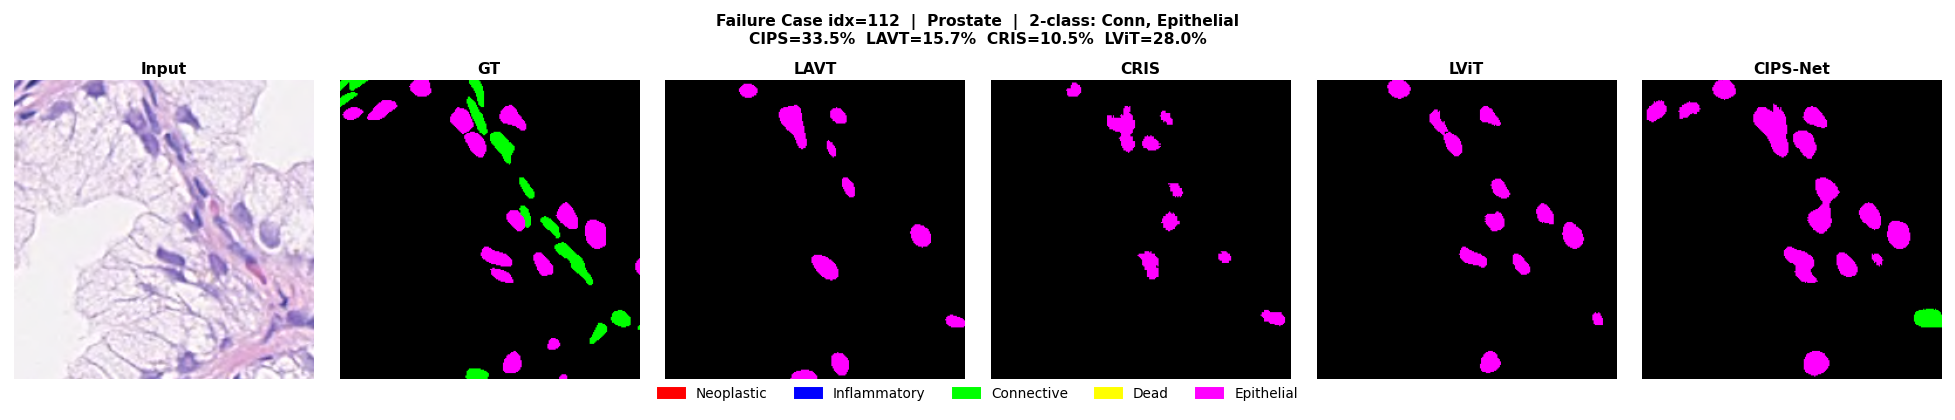

In [13]:
# ── Check idx=112 failure case ────────────────────────────────────────────
fail_idx = 112
fail_row = df_mpq[df_mpq['idx'] == fail_idx].iloc[0]
print(f"Failure case idx={fail_idx}:")
print(f"  Tissue: {fail_row['tissue']}")
print(f"  Classes: {fail_row['classes']}")
print(f"  CIPS-Net mPQ: {fail_row['cips_mpq']:.1f}%")
print(f"  LAVT mPQ: {fail_row['lavt_mpq']:.1f}%")
print(f"  CRIS mPQ: {fail_row['cris_mpq']:.1f}%")
print(f"  LViT mPQ: {fail_row['lvit_mpq']:.1f}%")
print(f"  Contrast: {fail_row['contrast']:+.1f}%")

# Display it
img_path = fail_row['image_path']
img_rgb, img_t = load_image_tensor(img_path)
static_row = df_static_tr[df_static_tr['image_path'] == img_path]
s_instr = static_row.iloc[0]['instruction']
cls_info = cls_per_img[cls_per_img['image_path'] == img_path].iloc[0]
class_set = cls_info['class_set']

# Run models
cips_rgb = type_map_to_rgb_combined(predict(img_t, s_instr))
lavt_rgb = type_map_to_rgb_combined(predict_hv(baseline_models["LAVT"], "LAVT", img_t, s_instr))
cris_rgb = type_map_to_rgb_combined(predict_hv(baseline_models["CRIS"], "CRIS", img_t, s_instr))
lvit_rgb = type_map_to_rgb_combined(predict_hv(baseline_models["LViT"], "LViT", img_t, s_instr))

# Build GT
gt_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
for cls_name in class_set:
    gt_cls = load_gt_class_mask(img_path, cls_name)
    if gt_cls is not None:
        mask = np.any(gt_cls > 10, axis=-1)
        gt_rgb[mask] = gt_cls[mask]

# Plot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLS = ["Input", "GT", "LAVT", "CRIS", "LViT", "CIPS-Net"]
imgs = [img_rgb, gt_rgb, lavt_rgb, cris_rgb, lvit_rgb, cips_rgb]

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5), dpi=140)
fig.suptitle(
    f"Failure Case idx={fail_idx}  |  {fail_row['tissue']}  |  {fail_row['n_gt']}-class: {fail_row['classes']}\n"
    f"CIPS={fail_row['cips_mpq']:.1f}%  LAVT={fail_row['lavt_mpq']:.1f}%  "
    f"CRIS={fail_row['cris_mpq']:.1f}%  LViT={fail_row['lvit_mpq']:.1f}%",
    fontsize=8, fontweight='bold', y=1.06,
)

for col_i, (img, title) in enumerate(zip(imgs, COLS)):
    ax = axes[col_i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=8, fontweight="bold", pad=3)

legend_patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS[i])/255, label=CLASS_NAMES[i])
    for i in [1, 2, 3, 4, 5]
]
fig.legend(handles=legend_patches, loc="lower center", ncol=5, fontsize=7,
           frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(pad=0.3)
plt.show()